# Deep Sequence Model Experiments

This notebook is a **separate parallel track** from notebook 26.

- `26_five_case_regime_experiments.ipynb` remains the principal paper notebook
- this notebook exists so the deep-learning models can be tested without touching or corrupting notebook 26
- the comparison here follows the same five-case narrative across the three datasets

It focuses on challenger-model evidence for the same representative demand cases.

Main paper question behind this notebook:

- if `SARIMAX` and `HURDLE` are already the strongest models in the switching framework, do newer challenger models actually beat them on the same products?
- can we show that with the same case-study products used in notebook 26 across the three datasets?

So this notebook compares the old strong baselines against the new requested models on the same products.

Current implemented / compared models in this notebook:

- SARIMAX
- HURDLE
- TSB
- CROSTON_SBA
- LSTM
- GRU
- DeepAR
- TCN
- Informer
- TFT
- N-BEATS
- LSTM-Transformer


In [1]:
import importlib
import sys

print('Notebook Python:', sys.executable)

required = ['numpy', 'pandas', 'torch', 'scipy']
missing = []
for pkg in required:
    try:
        importlib.import_module(pkg)
        print(f'OK {pkg}')
    except ModuleNotFoundError:
        missing.append(pkg)

if missing:
    raise ModuleNotFoundError(
        f'Missing packages in this kernel: {missing}. Install them in the notebook kernel before running.'
    )
else:
    print('All required packages are available in the current kernel.')


Notebook Python: c:\Users\braya\AppData\Local\Programs\Python\Python311\python.exe
OK numpy
OK pandas
OK torch
OK scipy
All required packages are available in the current kernel.


In [2]:
from pathlib import Path
import sys

def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for _ in range(8):
        if (cur / 'src').exists() and (cur / 'reports').exists():
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    return start.resolve()

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print('Repo root:', REPO_ROOT)


Repo root: C:\Users\braya\Documents\Research\aurex-demand-forecasting-main


In [3]:
import numpy as np
import pandas as pd
try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except Exception as e:
    print('Matplotlib disabled:', e)
    MATPLOTLIB_AVAILABLE = False
    plt = None
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from IPython.display import HTML, display

from src.experiments.run_cross_market_peak_comparison import (
    _load_amazon_selected,
    _load_favorita_selected,
    _load_m5_selected,
)
from src.models.advanced_deep_forecast_models import (
    InformerForecastModel,
    LSTMForecastModel as AdvancedLSTMForecastModel,
    LSTMTransformerForecastModel,
    NBEATSForecastModel,
    TCNForecastModel,
    TFTForecastModel,
)
from src.models.croston_model import CrostonSBAModel
from src.models.deep_challenger_models import (
    GRUForecastModel,
    DeepARForecastModel,
    DeepTrainingConfig,
    _as_float_array,
    _build_windows,
    _choose_device,
    _normal_quantile_975,
    _series_scale,
    mae,
    rmse,
    smape,
    train_test_split_series,
)
from src.models.hurdle_model import HurdleModel
from src.models.sarimax_model import SARIMAXModel
from src.models.tsb_model import TSBModel, sbc_classify

print('Imports OK')


Imports OK


## Model Scope

We separate the models into three groups:

1. strong existing baselines we want to defend or challenge
2. challenger models already runnable in this notebook
3. the final regime-consistency interpretation after all comparisons


In [4]:
model_scope = pd.DataFrame([
    {'model': 'SARIMAX', 'group': 'existing_strong_baseline', 'status': 'implemented_in_repo', 'notes': 'Main dense-demand baseline and one of the current strongest candidates.'},
    {'model': 'HURDLE', 'group': 'existing_strong_baseline', 'status': 'implemented_in_repo', 'notes': 'Main zero-heavy / erratic baseline and one of the current strongest candidates.'},
    {'model': 'TSB', 'group': 'existing_reference_baseline', 'status': 'implemented_in_repo', 'notes': 'Included as intermittent-demand reference even if it previously underperformed.'},
    {'model': 'CROSTON_SBA', 'group': 'existing_reference_baseline', 'status': 'implemented_in_repo', 'notes': 'Included as intermittent-demand reference even if it previously underperformed.'},
    {'model': 'LSTM', 'group': 'challenger_model', 'status': 'implemented_in_repo', 'notes': 'Advanced recurrent challenger using the shared recursive forecasting interface.'},
    {'model': 'GRU', 'group': 'challenger_model', 'status': 'implemented_in_repo', 'notes': 'Uses src.models.deep_challenger_models.GRUForecastModel.'},
    {'model': 'DeepAR', 'group': 'challenger_model', 'status': 'implemented_in_repo', 'notes': 'Uses src.models.deep_challenger_models.DeepARForecastModel.'},
    {'model': 'TCN', 'group': 'challenger_model', 'status': 'implemented_in_repo', 'notes': 'Dilated causal convolutional challenger for nonlinear temporal patterns.'},
    {'model': 'Informer', 'group': 'challenger_model', 'status': 'implemented_in_repo', 'notes': 'Lightweight Informer-style transformer challenger for long-context forecasting.'},
    {'model': 'TFT', 'group': 'challenger_model', 'status': 'implemented_in_repo', 'notes': 'Lightweight Temporal Fusion Transformer style challenger.'},
    {'model': 'N-BEATS', 'group': 'challenger_model', 'status': 'implemented_in_repo', 'notes': 'Residual block challenger inspired by N-BEATS for univariate demand forecasting.'},
    {'model': 'LSTM-Transformer', 'group': 'challenger_model', 'status': 'implemented_in_repo', 'notes': 'Hybrid recurrent-attention challenger for sequence modeling.'},
])
display(model_scope)


,model,group,status,notes
0,SARIMAX,existing_strong_baseline,implemented_in_repo,Main dense-demand baseline and one of the curr...
1,HURDLE,existing_strong_baseline,implemented_in_repo,Main zero-heavy / erratic baseline and one of ...
2,TSB,existing_reference_baseline,implemented_in_repo,Included as intermittent-demand reference even...
3,CROSTON_SBA,existing_reference_baseline,implemented_in_repo,Included as intermittent-demand reference even...
4,LSTM,challenger_model,implemented_in_repo,Advanced recurrent challenger using the shared...
5,GRU,challenger_model,implemented_in_repo,Uses src.models.deep_challenger_models.GRUFore...
6,DeepAR,challenger_model,implemented_in_repo,Uses src.models.deep_challenger_models.DeepARF...
7,TCN,challenger_model,implemented_in_repo,Dilated causal convolutional challenger for no...
8,Informer,challenger_model,implemented_in_repo,Lightweight Informer-style transformer challen...
9,TFT,challenger_model,implemented_in_repo,Lightweight Temporal Fusion Transformer style ...


## Representative Cases

To keep the paper story consistent, this notebook reuses the same representative five-case logic as notebook 26.

That means the evidence is directly comparable: same products, same datasets, different model family comparison.


In [5]:
experiment_cases = [
    {
        'dataset': 'FAVORITA',
        'series_id': 'item_268443',
        'expected_regime': 'high-demand',
        'semantic_product': 'Cleaning product - high demand / dense sales',
    },
    {
        'dataset': 'FAVORITA',
        'series_id': 'item_789224',
        'expected_regime': 'erratic',
        'semantic_product': 'Cleaning product - erratic transition case',
    },
    {
        'dataset': 'M5_WALMART',
        'series_id': 'HOUSEHOLD_1_187_WI_1_validation',
        'expected_regime': 'lumpy',
        'semantic_product': 'Household retail - lumpy / zero-heavy',
    },
    {
        'dataset': 'AMAZON_2023',
        'series_id': 'B0BZTL57BP',
        'expected_regime': 'intermittent',
        'semantic_product': 'Household hygiene - intermittent demand',
    },
    {
        'dataset': 'AMAZON_2023',
        'series_id': 'B0BR4W8TBH',
        'expected_regime': 'ultra-sparse intermittent',
        'semantic_product': 'Personal care - ultra sparse intermittent demand',
    },
]

display(pd.DataFrame(experiment_cases))


,dataset,series_id,expected_regime,semantic_product
0,FAVORITA,item_268443,high-demand,Cleaning product - high demand / dense sales
1,FAVORITA,item_789224,erratic,Cleaning product - erratic transition case
2,M5_WALMART,HOUSEHOLD_1_187_WI_1_validation,lumpy,Household retail - lumpy / zero-heavy
3,AMAZON_2023,B0BZTL57BP,intermittent,Household hygiene - intermittent demand
4,AMAZON_2023,B0BR4W8TBH,ultra-sparse intermittent,Personal care - ultra sparse intermittent demand


In [6]:
m5_ids = [c['series_id'] for c in experiment_cases if c['dataset'] == 'M5_WALMART']
fav_ids = [c['series_id'] for c in experiment_cases if c['dataset'] == 'FAVORITA']
amz_ids = [c['series_id'] for c in experiment_cases if c['dataset'] == 'AMAZON_2023']

series_map_by_ds = {
    'M5_WALMART': _load_m5_selected(str(REPO_ROOT / 'data' / 'raw' / 'm5'), m5_ids),
    'FAVORITA': _load_favorita_selected(str(REPO_ROOT / 'data' / 'raw' / 'favorita'), fav_ids, store_nbr=1),
    'AMAZON_2023': _load_amazon_selected(
        str(REPO_ROOT / 'data' / 'raw' / 'amazon_2023' / 'review_categories'),
        'Health_and_Household.jsonl.gz',
        amz_ids,
        max_rows=200000,
    ),
}

{k: list(v.keys()) for k, v in series_map_by_ds.items()}


{'M5_WALMART': ['HOUSEHOLD_1_187_WI_1_validation'],
 'FAVORITA': ['item_268443', 'item_789224'],
 'AMAZON_2023': ['B0BZTL57BP', 'B0BR4W8TBH']}

In [7]:
class _LSTMNet(nn.Module):
    def __init__(self, hidden_size: int, num_layers: int, dropout: float):
        super().__init__()
        lstm_dropout = dropout if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=lstm_dropout,
            batch_first=True,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        return self.head(last_hidden).squeeze(-1)


class LSTMForecastModel:
    def __init__(self, **kwargs):
        self.config = DeepTrainingConfig(**kwargs)
        self.device = _choose_device(self.config.device)
        self.model = _LSTMNet(
            hidden_size=self.config.hidden_size,
            num_layers=self.config.num_layers,
            dropout=self.config.dropout,
        ).to(self.device)
        self.scale_ = 1.0
        self.train_resid_std_ = 0.0
        self.training_history_ = {}

    def fit(self, y_train: np.ndarray):
        torch.manual_seed(self.config.seed)
        np.random.seed(self.config.seed)

        y = _as_float_array(y_train)
        self.scale_ = _series_scale(y)
        y_scaled = (y / self.scale_).astype(np.float32)

        X, target = _build_windows(y_scaled, self.config.context_length)
        ds = TensorDataset(
            torch.from_numpy(X).unsqueeze(-1),
            torch.from_numpy(target),
        )
        loader = DataLoader(ds, batch_size=self.config.batch_size, shuffle=True)

        optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=self.config.lr,
            weight_decay=self.config.weight_decay,
        )
        loss_fn = nn.MSELoss()

        final_loss = None
        self.model.train()
        for _ in range(self.config.epochs):
            epoch_losses = []
            for batch_x, batch_y in loader:
                batch_x = batch_x.to(self.device)
                batch_y = batch_y.to(self.device)
                optimizer.zero_grad()
                pred = self.model(batch_x)
                loss = loss_fn(pred, batch_y)
                loss.backward()
                optimizer.step()
                epoch_losses.append(float(loss.item()))
            final_loss = float(np.mean(epoch_losses)) if epoch_losses else None

        fitted = self._predict_in_sample_scaled(X) * self.scale_
        resid = y[self.config.context_length:] - fitted
        self.train_resid_std_ = float(np.std(resid)) if len(resid) else 0.0
        self.training_history_ = {'final_loss': final_loss if final_loss is not None else float('nan')}
        return self

    def _predict_in_sample_scaled(self, X: np.ndarray) -> np.ndarray:
        self.model.eval()
        with torch.no_grad():
            tensor_x = torch.from_numpy(X).unsqueeze(-1).to(self.device)
            pred = self.model(tensor_x).detach().cpu().numpy()
        return pred.astype(float)

    def forecast(self, h: int, y_history: np.ndarray):
        history = list((_as_float_array(y_history) / self.scale_).astype(np.float32))
        preds_scaled = []

        self.model.eval()
        with torch.no_grad():
            for _ in range(int(h)):
                context = np.asarray(history[-self.config.context_length:], dtype=np.float32)
                if len(context) < self.config.context_length:
                    context = np.pad(context, (self.config.context_length - len(context), 0))
                x = torch.from_numpy(context).view(1, self.config.context_length, 1).to(self.device)
                next_pred = float(self.model(x).item())
                preds_scaled.append(next_pred)
                history.append(next_pred)

        y_pred = np.maximum(np.asarray(preds_scaled, dtype=float) * self.scale_, 0.0)
        spread = _normal_quantile_975() * max(self.train_resid_std_, 1e-6)
        conf_low = np.maximum(y_pred - spread, 0.0)
        conf_up = y_pred + spread
        return y_pred, conf_low, conf_up


print('LSTM model ready')


LSTM model ready


In [8]:
def build_features(df):
    out = df.copy().sort_values('date').reset_index(drop=True)
    out['date'] = pd.to_datetime(out['date'])
    if 'price' not in out.columns:
        out['price'] = np.nan
    out['price'] = out['price'].ffill().bfill().fillna(0.0)

    out['dow'] = out['date'].dt.dayofweek
    out['month'] = out['date'].dt.month
    out['is_weekend'] = (out['dow'] >= 5).astype(int)

    out['lag_1'] = out['sales'].shift(1)
    out['lag_7'] = out['sales'].shift(7)
    out['lag_14'] = out['sales'].shift(14)
    out['lag_28'] = out['sales'].shift(28)

    out['ma_7'] = out['sales'].rolling(7, min_periods=1).mean()
    out['ma_14'] = out['sales'].rolling(14, min_periods=1).mean()
    out['ma_30'] = out['sales'].rolling(30, min_periods=1).mean()
    out['std_7'] = out['sales'].rolling(7, min_periods=1).std().fillna(0.0)

    out['days_since_sale'] = (out['sales'] == 0).astype(int).groupby((out['sales'] > 0).cumsum()).cumsum()
    out['sold_yesterday'] = (out['lag_1'] > 0).astype(int)
    out['trend_7'] = (out['ma_7'] - out['ma_7'].shift(7)).fillna(0.0)

    feature_cols = [
        'price', 'dow', 'month', 'is_weekend',
        'lag_1', 'lag_7', 'lag_14', 'lag_28',
        'ma_7', 'ma_14', 'ma_30', 'std_7',
        'days_since_sale', 'sold_yesterday', 'trend_7',
    ]
    out[feature_cols] = out[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return out, feature_cols


def _svg_polyline_points(values, x0, y0, width, height, vmin, vmax):
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return ''
    if len(values) == 1:
        xs = np.array([x0 + width / 2.0])
    else:
        xs = np.linspace(x0, x0 + width, len(values))
    denom = max(vmax - vmin, 1e-9)
    ys = y0 + height - ((values - vmin) / denom) * height
    return ' '.join(f'{float(x):.2f},{float(y):.2f}' for x, y in zip(xs, ys))


def render_case_forecast_svg(case: dict, case_rows, plot_groups: list[list[str]] | None = None, models_per_chart: int = 3):
    width = 980
    height = 360
    margin_left, margin_right, margin_top, margin_bottom = 70, 20, 30, 55
    plot_width = width - margin_left - margin_right
    plot_height = height - margin_top - margin_bottom

    actual = np.asarray(case_rows[0]['y_test'], dtype=float)
    colors = {
        'Actual': '#111111',
        'SARIMAX': '#1f77b4',
        'HURDLE': '#d62728',
        'TSB': '#2ca02c',
        'CROSTON_SBA': '#8c564b',
        'LSTM': '#9467bd',
        'GRU': '#e377c2',
        'DeepAR': '#17becf',
        'TCN': '#ff7f0e',
        'Informer': '#7f7f7f',
        'TFT': '#bcbd22',
        'N-BEATS': '#00a896',
        'LSTM-Transformer': '#9c6644',
    }

    if plot_groups is None:
        plot_groups = [
            ['SARIMAX', 'HURDLE', 'TSB'],
            ['CROSTON_SBA', 'LSTM', 'GRU'],
            ['DeepAR', 'TCN', 'Informer'],
            ['TFT', 'N-BEATS', 'LSTM-Transformer'],
        ]

    row_map = {row['model']: row for row in case_rows}
    chunks = []
    for group in plot_groups:
        chunk_rows = [row_map[m] for m in group if m in row_map]
        if chunk_rows:
            chunks.append((group, chunk_rows))

    remaining_rows = [row for row in case_rows if row['model'] not in {m for g in plot_groups for m in g}]
    for i in range(0, len(remaining_rows), models_per_chart):
        extra_rows = remaining_rows[i:i + models_per_chart]
        if extra_rows:
            chunks.append(([row['model'] for row in extra_rows], extra_rows))

    for chunk_idx, (group_names, chunk_rows) in enumerate(chunks, start=1):
        series = [actual] + [np.asarray(r['y_pred'], dtype=float) for r in chunk_rows]
        vmax = max(float(np.max(s)) for s in series) if series else 1.0
        vmin = min(0.0, min(float(np.min(s)) for s in series)) if series else 0.0
        if abs(vmax - vmin) < 1e-9:
            vmax = vmin + 1.0

        grid_lines = []
        for frac in np.linspace(0, 1, 5):
            y = margin_top + plot_height * frac
            value = vmax - frac * (vmax - vmin)
            grid_lines.append(f"<line x1='{margin_left}' y1='{y:.2f}' x2='{margin_left + plot_width}' y2='{y:.2f}' stroke='#dddddd' stroke-width='1' />")
            grid_lines.append(f"<text x='{margin_left - 8}' y='{y + 4:.2f}' text-anchor='end' font-size='11' fill='#555'>{value:.2f}</text>")

        polylines = []
        actual_points = _svg_polyline_points(actual, margin_left, margin_top, plot_width, plot_height, vmin, vmax)
        polylines.append(f"<polyline fill='none' stroke='{colors['Actual']}' stroke-width='3' points='{actual_points}' />")
        for row in chunk_rows:
            points = _svg_polyline_points(row['y_pred'], margin_left, margin_top, plot_width, plot_height, vmin, vmax)
            color = colors.get(row['model'], '#666666')
            polylines.append(f"<polyline fill='none' stroke='{color}' stroke-width='2' stroke-opacity='0.9' points='{points}' />")

        legend_items = ["<rect x='0' y='0' width='12' height='12' fill='#111111' /><text x='18' y='10' font-size='12'>Actual</text>"]
        for row in chunk_rows:
            color = colors.get(row['model'], '#666666')
            legend_items.append(f"<rect x='0' y='0' width='12' height='12' fill='{color}' /><text x='18' y='10' font-size='12'>{row['model']}</text>")
        legend_svg = []
        for i, item in enumerate(legend_items):
            x = margin_left + (i % 4) * 180
            y = height - 28 + (i // 4) * 18
            legend_svg.append(f"<g transform='translate({x},{y})'>{item}</g>")

        title = f"{case['semantic_product']} | {case['dataset']} | {case['series_id']} | Group {chunk_idx}/{len(chunks)} | {', '.join(group_names)}"
        svg = f"""
<svg width='{width}' height='{height + 24}' xmlns='http://www.w3.org/2000/svg'>
  <rect x='0' y='0' width='{width}' height='{height + 24}' fill='white' />
  <text x='{margin_left}' y='20' font-size='15' font-weight='bold' fill='#222'>{title}</text>
  <line x1='{margin_left}' y1='{margin_top}' x2='{margin_left}' y2='{margin_top + plot_height}' stroke='#888' stroke-width='1.2' />
  <line x1='{margin_left}' y1='{margin_top + plot_height}' x2='{margin_left + plot_width}' y2='{margin_top + plot_height}' stroke='#888' stroke-width='1.2' />
  {''.join(grid_lines)}
  {''.join(polylines)}
  {''.join(legend_svg)}
</svg>
"""
        display(HTML(svg))


def prepare_case_data(case: dict, test_days: int = 365) -> dict:
    ds = case['dataset']
    sid = case['series_id']
    base_df = series_map_by_ds[ds][sid].copy().sort_values('date').reset_index(drop=True)
    feat_df, feature_cols = build_features(base_df)
    y = pd.to_numeric(feat_df['sales'], errors='coerce').fillna(0.0).to_numpy(dtype=float)
    y_train, y_test = train_test_split_series(y, test_days=test_days)
    train_df = feat_df.iloc[:len(y_train)].copy()
    test_df = feat_df.iloc[len(y_train):].copy()
    X_train = train_df[feature_cols].astype(float).values
    X_test = test_df[feature_cols].astype(float).values
    return {
        'base_df': base_df,
        'feat_df': feat_df,
        'feature_cols': feature_cols,
        'y': y,
        'y_train': y_train,
        'y_test': y_test,
        'train_df': train_df,
        'test_df': test_df,
        'X_train': X_train,
        'X_test': X_test,
    }


def evaluate_case_model(case: dict, model_name: str, model_spec: dict, prepared: dict | None = None, test_days: int = 365) -> dict:
    ds = case['dataset']
    sid = case['series_id']
    prepared = prepared or prepare_case_data(case, test_days=test_days)
    base_df = prepared['base_df']
    y_train = prepared['y_train']
    y_test = prepared['y_test']
    train_df = prepared['train_df']
    test_df = prepared['test_df']
    X_train = prepared['X_train']
    X_test = prepared['X_test']

    model = model_spec['factory']()
    family = model_spec['family']

    if family == 'feature_based':
        model.fit(y_train, X_train)
        y_pred, conf_low, conf_up = model.forecast(len(y_test), X_test)
    elif family == 'hurdle':
        model.fit(X_train, y_train)
        y_pred, conf_low, conf_up = model.forecast(X_test, X_train, y_train)
    elif family == 'intermittent_univariate':
        model.fit(y_train)
        y_pred, conf_low, conf_up = model.forecast(len(y_test))
    elif family == 'deep_autoregressive':
        model.fit(y_train)
        y_pred, conf_low, conf_up = model.forecast(len(y_test), y_train)
    else:
        raise ValueError(f'Unknown model family: {family}')

    sbc = sbc_classify(y_train)

    return {
        'dataset': ds,
        'series_id': sid,
        'semantic_product': case['semantic_product'],
        'expected_regime': case['expected_regime'],
        'model': model_name,
        'model_group': model_spec['group'],
        'model_family': family,
        'train_days': len(y_train),
        'test_days': len(y_test),
        'zero_rate_train': float((y_train == 0).mean()),
        'ADI_train': sbc.get('adi'),
        'CV2_train': sbc.get('cv2'),
        'sbc_regime_train': sbc.get('regime'),
        'mae': mae(y_test, y_pred),
        'rmse': rmse(y_test, y_pred),
        'smape': smape(y_test, y_pred),
        'final_loss': getattr(model, 'training_history_', {}).get('final_loss'),
        'y_test': y_test,
        'y_pred': y_pred,
        'conf_low': conf_low,
        'conf_up': conf_up,
        'test_dates': base_df['date'].iloc[-len(y_test):].reset_index(drop=True),
    }


BENCHMARK_EPOCHS = 8
BENCHMARK_TEST_DAYS = 365
BENCHMARK_MODEL_NAMES = [
    'SARIMAX', 'HURDLE', 'TSB', 'CROSTON_SBA',
    'LSTM', 'GRU', 'DeepAR', 'TCN', 'Informer', 'TFT', 'N-BEATS', 'LSTM-Transformer',
]
BENCHMARK_CASE_IDS = [c['series_id'] for c in experiment_cases]

model_factories = {
    'SARIMAX': {'factory': lambda: SARIMAXModel(), 'family': 'feature_based', 'group': 'existing_strong_baseline'},
    'HURDLE': {'factory': lambda: HurdleModel(), 'family': 'hurdle', 'group': 'existing_strong_baseline'},
    'TSB': {'factory': lambda: TSBModel(), 'family': 'intermittent_univariate', 'group': 'existing_reference_baseline'},
    'CROSTON_SBA': {'factory': lambda: CrostonSBAModel(), 'family': 'intermittent_univariate', 'group': 'existing_reference_baseline'},
    'LSTM': {'factory': lambda: AdvancedLSTMForecastModel(context_length=28, hidden_size=32, epochs=BENCHMARK_EPOCHS), 'family': 'deep_autoregressive', 'group': 'challenger_model'},
    'GRU': {'factory': lambda: GRUForecastModel(context_length=28, hidden_size=32, epochs=BENCHMARK_EPOCHS), 'family': 'deep_autoregressive', 'group': 'challenger_model'},
    'DeepAR': {'factory': lambda: DeepARForecastModel(context_length=28, hidden_size=32, epochs=BENCHMARK_EPOCHS), 'family': 'deep_autoregressive', 'group': 'challenger_model'},
    'TCN': {'factory': lambda: TCNForecastModel(context_length=28, hidden_size=32, epochs=BENCHMARK_EPOCHS, dropout=0.1), 'family': 'deep_autoregressive', 'group': 'challenger_model'},
    'Informer': {'factory': lambda: InformerForecastModel(context_length=28, hidden_size=32, num_layers=2, epochs=BENCHMARK_EPOCHS, dropout=0.1), 'family': 'deep_autoregressive', 'group': 'challenger_model'},
    'TFT': {'factory': lambda: TFTForecastModel(context_length=28, hidden_size=32, num_layers=2, epochs=BENCHMARK_EPOCHS, dropout=0.1), 'family': 'deep_autoregressive', 'group': 'challenger_model'},
    'N-BEATS': {'factory': lambda: NBEATSForecastModel(context_length=28, hidden_size=64, num_layers=2, epochs=BENCHMARK_EPOCHS, dropout=0.1), 'family': 'deep_autoregressive', 'group': 'challenger_model'},
    'LSTM-Transformer': {'factory': lambda: LSTMTransformerForecastModel(context_length=28, hidden_size=32, num_layers=2, epochs=BENCHMARK_EPOCHS, dropout=0.1), 'family': 'deep_autoregressive', 'group': 'challenger_model'},
}

print('Benchmark helpers ready')


Benchmark helpers ready


In [9]:
import time

selected_cases = [c for c in experiment_cases if c['series_id'] in BENCHMARK_CASE_IDS]
selected_model_items = [(name, spec) for name, spec in model_factories.items() if name in BENCHMARK_MODEL_NAMES]
total_runs = len(selected_cases) * len(selected_model_items)

results = []
run_idx = 0
overall_t0 = time.perf_counter()
prepared_case_cache = {}

print(
    f"Running {len(selected_cases)} cases x {len(selected_model_items)} models = {total_runs} runs "
    f"(test_days={BENCHMARK_TEST_DAYS}, epochs={BENCHMARK_EPOCHS})"
)

for case in selected_cases:
    key_ok = case['series_id'] in series_map_by_ds.get(case['dataset'], {})
    if not key_ok:
        print(f"[WARN] Missing series: {case['dataset']} -> {case['series_id']}")
        continue

    case_key = (case['dataset'], case['series_id'])
    if case_key not in prepared_case_cache:
        prep_t0 = time.perf_counter()
        prepared_case_cache[case_key] = prepare_case_data(case, test_days=BENCHMARK_TEST_DAYS)
        prep_elapsed = time.perf_counter() - prep_t0
        print(
            f"[PREP] {case['dataset']} | {case['series_id']} prepared in {prep_elapsed:.1f}s"
        )
    prepared_case = prepared_case_cache[case_key]

    for model_name, model_spec in selected_model_items:
        run_idx += 1
        run_t0 = time.perf_counter()
        print(f"[RUN {run_idx}/{total_runs}] {case['dataset']} | {case['series_id']} | {model_name}")
        try:
            result = evaluate_case_model(case, model_name, model_spec, prepared=prepared_case, test_days=BENCHMARK_TEST_DAYS)
            results.append(result)
            run_elapsed = time.perf_counter() - run_t0
            total_elapsed = time.perf_counter() - overall_t0
            avg_per_run = total_elapsed / run_idx
            eta_seconds = avg_per_run * (total_runs - run_idx)
            print(
                f"  -> done in {run_elapsed:.1f}s | MAE={result['mae']:.4f} | elapsed={total_elapsed/60:.1f}m | ETA={eta_seconds/60:.1f}m"
            )
        except Exception as exc:
            run_elapsed = time.perf_counter() - run_t0
            print(f"[WARN] {model_name} failed on {case['series_id']} after {run_elapsed:.1f}s: {exc}")

print(f"Total completed runs: {len(results)} in {(time.perf_counter() - overall_t0)/60:.1f} minutes")


Running 5 cases x 12 models = 60 runs (test_days=365, epochs=8)
[PREP] FAVORITA | item_268443 prepared in 0.1s
[RUN 1/60] FAVORITA | item_268443 | SARIMAX


c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optim

  -> done in 37.7s | MAE=3.6723 | elapsed=0.6m | ETA=37.1m
[RUN 2/60] FAVORITA | item_268443 | HURDLE
  -> done in 0.0s | MAE=2.9282 | elapsed=0.6m | ETA=18.2m
[RUN 3/60] FAVORITA | item_268443 | TSB
  -> done in 0.1s | MAE=5.3850 | elapsed=0.6m | ETA=12.0m
[RUN 4/60] FAVORITA | item_268443 | CROSTON_SBA
  -> done in 0.0s | MAE=5.5172 | elapsed=0.6m | ETA=8.8m
[RUN 5/60] FAVORITA | item_268443 | LSTM


C:\Users\braya\AppData\Local\Temp\ipykernel_127944\2826264685.py:188: UserWarning: 
[TSBModel] Series is in 'erratic' regime (ADI=1.17, CV²=0.643).  TSB is optimal in the 'intermittent' quadrant (ADI > 1.32, CV² < 0.49).  Consider using HURDLE for this product instead.
  model.fit(y_train)


  -> done in 8.2s | MAE=7.0262 | elapsed=0.8m | ETA=8.4m
[RUN 6/60] FAVORITA | item_268443 | GRU
  -> done in 7.8s | MAE=7.0818 | elapsed=0.9m | ETA=8.1m
[RUN 7/60] FAVORITA | item_268443 | DeepAR
  -> done in 3.7s | MAE=7.2409 | elapsed=1.0m | ETA=7.3m
[RUN 8/60] FAVORITA | item_268443 | TCN
  -> done in 6.9s | MAE=6.9352 | elapsed=1.1m | ETA=7.0m
[RUN 9/60] FAVORITA | item_268443 | Informer
  -> done in 16.7s | MAE=6.0238 | elapsed=1.4m | ETA=7.7m
[RUN 10/60] FAVORITA | item_268443 | TFT
  -> done in 10.8s | MAE=6.7330 | elapsed=1.5m | ETA=7.7m
[RUN 11/60] FAVORITA | item_268443 | N-BEATS
  -> done in 5.1s | MAE=6.4787 | elapsed=1.6m | ETA=7.2m
[RUN 12/60] FAVORITA | item_268443 | LSTM-Transformer
  -> done in 13.6s | MAE=5.8077 | elapsed=1.8m | ETA=7.4m
[PREP] FAVORITA | item_789224 prepared in 0.0s
[RUN 13/60] FAVORITA | item_789224 | SARIMAX


...

  -> done in 27.1s | MAE=0.3723 | elapsed=4.0m | ETA=5.6m
[RUN 26/60] M5_WALMART | HOUSEHOLD_1_187_WI_1_validation | HURDLE
  -> done in 0.0s | MAE=0.6794 | elapsed=4.0m | ETA=5.3m
[RUN 27/60] M5_WALMART | HOUSEHOLD_1_187_WI_1_validation | TSB
  -> done in 0.1s | MAE=0.3844 | elapsed=4.0m | ETA=4.9m
[RUN 28/60] M5_WALMART | HOUSEHOLD_1_187_WI_1_validation | CROSTON_SBA
  -> done in 0.0s | MAE=0.2695 | elapsed=4.0m | ETA=4.6m
[RUN 29/60] M5_WALMART | HOUSEHOLD_1_187_WI_1_validation | LSTM
  -> done in 3.5s | MAE=0.3999 | elapsed=4.1m | ETA=4.4m
[RUN 30/60] M5_WALMART | HOUSEHOLD_1_187_WI_1_validation | GRU
  -> done in 9.1s | MAE=0.3964 | elapsed=4.2m | ETA=4.2m
[RUN 31/60] M5_WALMART | HOUSEHOLD_1_187_WI_1_validation | DeepAR
  -> done in 4.3s | MAE=0.3478 | elapsed=4.3m | ETA=4.0m
[RUN 32/60] M5_WALMART | HOUSEHOLD_1_187_WI_1_validation | TCN
  -> done in 8.0s | MAE=0.2630 | elapsed=4.4m | ETA=3.9m
[RUN 33/60] M5_WALMART | HOUSEHOLD_1_187_WI_1_validation | Informer
  -> done in 19.6s 

c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  -> done in 60.4s | MAE=0.0952 | elapsed=6.3m | ETA=3.9m
[RUN 38/60] AMAZON_2023 | B0BZTL57BP | HURDLE
  -> done in 0.0s | MAE=0.1160 | elapsed=6.3m | ETA=3.7m
[RUN 39/60] AMAZON_2023 | B0BZTL57BP | TSB
  -> done in 0.1s | MAE=0.0433 | elapsed=6.3m | ETA=3.4m
[RUN 40/60] AMAZON_2023 | B0BZTL57BP | CROSTON_SBA
  -> done in 0.0s | MAE=0.0697 | elapsed=6.3m | ETA=3.2m
[RUN 41/60] AMAZON_2023 | B0BZTL57BP | LSTM
  -> done in 6.0s | MAE=0.0903 | elapsed=6.4m | ETA=3.0m
[RUN 42/60] AMAZON_2023 | B0BZTL57BP | GRU
  -> done in 14.1s | MAE=0.0908 | elapsed=6.7m | ETA=2.9m
[RUN 43/60] AMAZON_2023 | B0BZTL57BP | DeepAR
  -> done in 5.6s | MAE=0.1181 | elapsed=6.7m | ETA=2.7m
[RUN 44/60] AMAZON_2023 | B0BZTL57BP | TCN
  -> done in 11.2s | MAE=0.0812 | elapsed=6.9m | ETA=2.5m
[RUN 45/60] AMAZON_2023 | B0BZTL57BP | Informer
  -> done in 25.5s | MAE=0.0784 | elapsed=7.4m | ETA=2.5m
[RUN 46/60] AMAZON_2023 | B0BZTL57BP | TFT
  -> done in 15.2s | MAE=0.1066 | elapsed=7.6m | ETA=2.3m
[RUN 47/60] AMAZON

c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optim

  -> done in 27.8s | MAE=0.1362 | elapsed=8.5m | ETA=1.9m
[RUN 50/60] AMAZON_2023 | B0BR4W8TBH | HURDLE
  -> done in 0.0s | MAE=0.0640 | elapsed=8.5m | ETA=1.7m
[RUN 51/60] AMAZON_2023 | B0BR4W8TBH | TSB
  -> done in 0.0s | MAE=0.0962 | elapsed=8.5m | ETA=1.5m
[RUN 52/60] AMAZON_2023 | B0BR4W8TBH | CROSTON_SBA
  -> done in 0.0s | MAE=0.0720 | elapsed=8.5m | ETA=1.3m
[RUN 53/60] AMAZON_2023 | B0BR4W8TBH | LSTM
  -> done in 2.9s | MAE=0.1189 | elapsed=8.6m | ETA=1.1m
[RUN 54/60] AMAZON_2023 | B0BR4W8TBH | GRU
  -> done in 6.6s | MAE=0.1252 | elapsed=8.7m | ETA=1.0m
[RUN 55/60] AMAZON_2023 | B0BR4W8TBH | DeepAR
  -> done in 2.6s | MAE=0.1508 | elapsed=8.7m | ETA=0.8m
[RUN 56/60] AMAZON_2023 | B0BR4W8TBH | TCN
  -> done in 6.0s | MAE=0.1006 | elapsed=8.8m | ETA=0.6m
[RUN 57/60] AMAZON_2023 | B0BR4W8TBH | Informer
  -> done in 13.6s | MAE=0.1457 | elapsed=9.0m | ETA=0.5m
[RUN 58/60] AMAZON_2023 | B0BR4W8TBH | TFT
  -> done in 9.7s | MAE=0.1058 | elapsed=9.2m | ETA=0.3m
[RUN 59/60] AMAZON_20

In [10]:
result_rows = [
    {k: v for k, v in row.items() if k not in ['y_test', 'y_pred', 'conf_low', 'conf_up', 'test_dates']}
    for row in results
]
results_df = pd.DataFrame(result_rows)

required_cols = ['dataset', 'series_id', 'mae']
if results_df.empty or any(col not in results_df.columns for col in required_cols):
    print('No benchmark results available yet. Run the benchmark cell first and check any [WARN] messages above.')
    print('Current results length:', len(results))
    display(results_df)
else:
    results_df = results_df.sort_values(required_cols).reset_index(drop=True)
    display(results_df)


,dataset,series_id,semantic_product,expected_regime,model,model_group,model_family,train_days,test_days,zero_rate_train,ADI_train,CV2_train,sbc_regime_train,mae,rmse,smape,final_loss
0,AMAZON_2023,B0BR4W8TBH,Personal care - ultra sparse intermittent demand,ultra-sparse intermittent,LSTM-Transformer,challenger_model,deep_autoregressive,1382,365,0.935601,15.528090,0.380408,intermittent,0.046557,0.171433,199.793003,0.085562
1,AMAZON_2023,B0BR4W8TBH,Personal care - ultra sparse intermittent demand,ultra-sparse intermittent,HURDLE,existing_strong_baseline,hurdle,1382,365,0.935601,15.528090,0.380408,intermittent,0.064003,0.158130,193.433639,NaN
2,AMAZON_2023,B0BR4W8TBH,Personal care - ultra sparse intermittent demand,ultra-sparse intermittent,CROSTON_SBA,existing_reference_baseline,intermittent_univariate,1382,365,0.935601,15.528090,0.380408,intermittent,0.071957,0.171567,199.486394,NaN
3,AMAZON_2023,B0BR4W8TBH,Personal care - ultra sparse intermittent demand,ultra-sparse intermittent,N-BEATS,challenger_model,deep_autoregressive,1382,365,0.935601,15.528090,0.380408,intermittent,0.094262,0.176528,199.239910,0.068139
4,AMAZON_2023,B0BR4W8TBH,Personal care - ultra sparse intermittent demand,ultra-sparse intermittent,TSB,existing_reference_baseline,intermittent_univariate,1382,365,0.935601,15.528090,0.380408,intermittent,0.096213,0.175622,199.208058,NaN
5,AMAZON_2023,B0BR4W8TBH,Personal care - ultra sparse intermittent demand,ultra-sparse intermittent,TCN,challenger_model,deep_autoregressive,1382,365,0.935601,15.528090,0.380408,intermittent,0.100648,0.176764,199.156921,0.085819
6,AMAZON_2023,B0BR4W8TBH,Personal care - ultra sparse intermittent demand,ultra-sparse intermittent,TFT,challenger_model,deep_autoregressive,1382,365,0.935601,15.528090,0.380408,intermittent,0.105772,0.178224,199.101999,0.085683
7,AMAZON_2023,B0BR4W8TBH,Personal care - ultra sparse intermittent demand,ultra-sparse intermittent,LSTM,challenger_model,deep_autoregressive,1382,365,0.935601,15.528090,0.380408,intermittent,0.118908,0.182666,198.959544,0.084128
8,AMAZON_2023,B0BR4W8TBH,Personal care - ultra sparse intermittent demand,ultra-sparse intermittent,GRU,challenger_model,deep_autoregressive,1382,365,0.935601,15.528090,0.380408,intermittent,0.125228,0.185140,198.892144,0.084144
9,AMAZON_2023,B0BR4W8TBH,Personal care - ultra sparse intermittent demand,ultra-sparse intermittent,SARIMAX,existing_strong_baseline,feature_based,1382,365,0.935601,15.528090,0.380408,intermittent,0.136163,0.237484,197.291684,NaN


In [11]:
best_by_case = (
    results_df.sort_values(['dataset', 'series_id', 'mae'])
    .groupby(['dataset', 'series_id', 'semantic_product', 'expected_regime'], as_index=False)
    .first()
    [['dataset', 'series_id', 'semantic_product', 'expected_regime', 'model', 'model_group', 'mae', 'rmse', 'smape']]
)
display(best_by_case)


,dataset,series_id,semantic_product,expected_regime,model,model_group,mae,rmse,smape
0,AMAZON_2023,B0BR4W8TBH,Personal care - ultra sparse intermittent demand,ultra-sparse intermittent,LSTM-Transformer,challenger_model,0.046557,0.171433,199.793003
1,AMAZON_2023,B0BZTL57BP,Household hygiene - intermittent demand,intermittent,LSTM-Transformer,challenger_model,0.035616,0.188723,200.000000
2,FAVORITA,item_268443,Cleaning product - high demand / dense sales,high-demand,HURDLE,existing_strong_baseline,2.928161,4.807279,84.141432
3,FAVORITA,item_789224,Cleaning product - erratic transition case,erratic,HURDLE,existing_strong_baseline,2.238927,3.228700,58.029056
4,M5_WALMART,HOUSEHOLD_1_187_WI_1_validation,Household retail - lumpy / zero-heavy,lumpy,TCN,challenger_model,0.262959,0.598589,196.382078


In [12]:
baseline_vs_challenger = []

for (dataset, series_id), grp in results_df.groupby(['dataset', 'series_id']):
    baseline = grp[grp['model_group'] == 'existing_strong_baseline'].sort_values('mae').head(1)
    challenger = grp[grp['model_group'] == 'challenger_model'].sort_values('mae').head(1)
    if baseline.empty or challenger.empty:
        continue
    b = baseline.iloc[0]
    c = challenger.iloc[0]
    baseline_vs_challenger.append({
        'dataset': dataset,
        'series_id': series_id,
        'semantic_product': b['semantic_product'],
        'expected_regime': b['expected_regime'],
        'best_existing_strong_baseline': b['model'],
        'baseline_mae': b['mae'],
        'best_challenger_model': c['model'],
        'challenger_mae': c['mae'],
        'challenger_minus_baseline_mae': c['mae'] - b['mae'],
        'winner': c['model'] if c['mae'] < b['mae'] else b['model'],
    })

baseline_vs_challenger_df = pd.DataFrame(baseline_vs_challenger).sort_values(['dataset', 'series_id']).reset_index(drop=True)
display(baseline_vs_challenger_df)


,dataset,series_id,semantic_product,expected_regime,best_existing_strong_baseline,baseline_mae,best_challenger_model,challenger_mae,challenger_minus_baseline_mae,winner
0,AMAZON_2023,B0BR4W8TBH,Personal care - ultra sparse intermittent demand,ultra-sparse intermittent,HURDLE,0.064003,LSTM-Transformer,0.046557,-0.017446,LSTM-Transformer
1,AMAZON_2023,B0BZTL57BP,Household hygiene - intermittent demand,intermittent,SARIMAX,0.095198,LSTM-Transformer,0.035616,-0.059581,LSTM-Transformer
2,FAVORITA,item_268443,Cleaning product - high demand / dense sales,high-demand,HURDLE,2.928161,LSTM-Transformer,5.807660,2.879499,HURDLE
3,FAVORITA,item_789224,Cleaning product - erratic transition case,erratic,HURDLE,2.238927,GRU,3.197238,0.958311,HURDLE
4,M5_WALMART,HOUSEHOLD_1_187_WI_1_validation,Household retail - lumpy / zero-heavy,lumpy,SARIMAX,0.372296,TCN,0.262959,-0.109337,TCN


In [13]:
regime_consistency_rows = []

for _, row in baseline_vs_challenger_df.iterrows():
    consistent_with_switching = row['winner'] == row['best_existing_strong_baseline']
    regime_consistency_rows.append({
        'dataset': row['dataset'],
        'series_id': row['series_id'],
        'semantic_product': row['semantic_product'],
        'expected_regime': row['expected_regime'],
        'baseline_candidate': row['best_existing_strong_baseline'],
        'best_challenger': row['best_challenger_model'],
        'winner': row['winner'],
        'supports_current_switching_view': consistent_with_switching,
        'mae_gap_challenger_minus_baseline': row['challenger_minus_baseline_mae'],
    })

regime_consistency_df = pd.DataFrame(regime_consistency_rows)
display(regime_consistency_df)
print('Cases supporting current switching view:', int(regime_consistency_df['supports_current_switching_view'].sum()), 'of', len(regime_consistency_df))


,dataset,series_id,semantic_product,expected_regime,baseline_candidate,best_challenger,winner,supports_current_switching_view,mae_gap_challenger_minus_baseline
0,AMAZON_2023,B0BR4W8TBH,Personal care - ultra sparse intermittent demand,ultra-sparse intermittent,HURDLE,LSTM-Transformer,LSTM-Transformer,False,-0.017446
1,AMAZON_2023,B0BZTL57BP,Household hygiene - intermittent demand,intermittent,SARIMAX,LSTM-Transformer,LSTM-Transformer,False,-0.059581
2,FAVORITA,item_268443,Cleaning product - high demand / dense sales,high-demand,HURDLE,LSTM-Transformer,HURDLE,True,2.879499
3,FAVORITA,item_789224,Cleaning product - erratic transition case,erratic,HURDLE,GRU,HURDLE,True,0.958311
4,M5_WALMART,HOUSEHOLD_1_187_WI_1_validation,Household retail - lumpy / zero-heavy,lumpy,SARIMAX,TCN,TCN,False,-0.109337


Cases supporting current switching view: 2 of 5


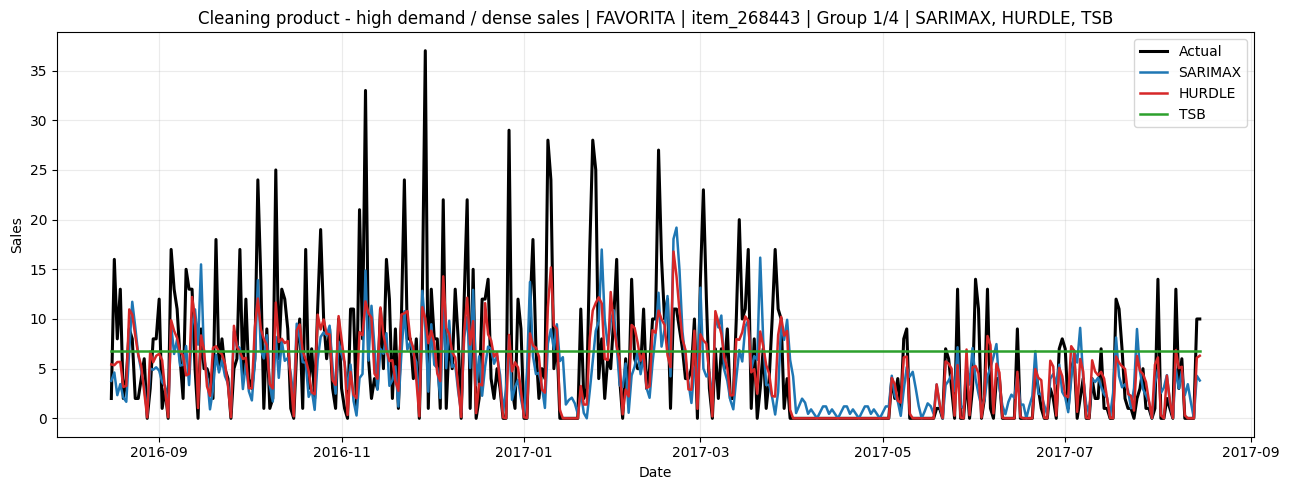

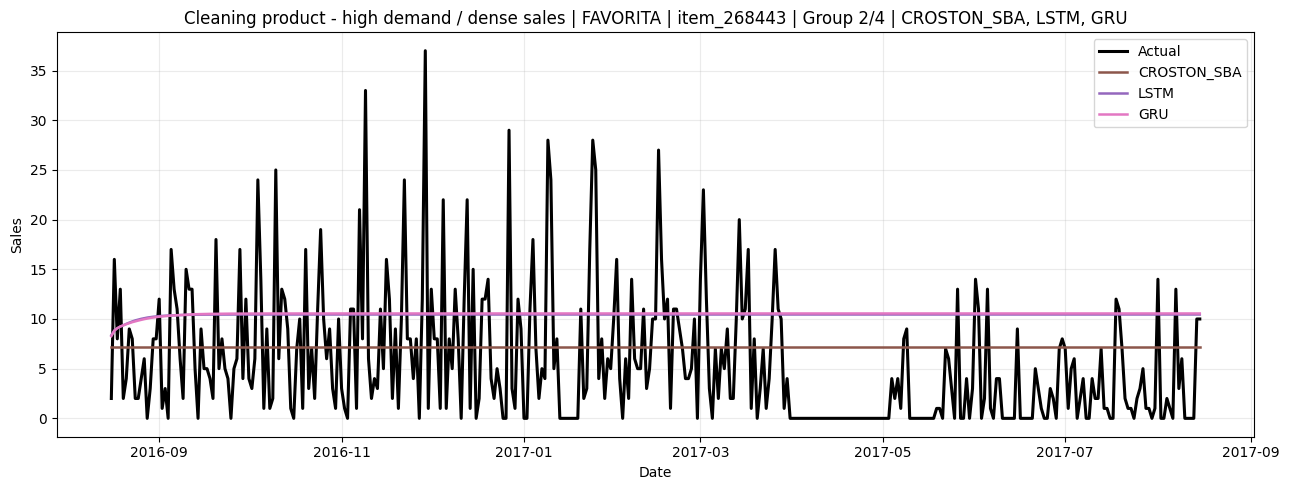

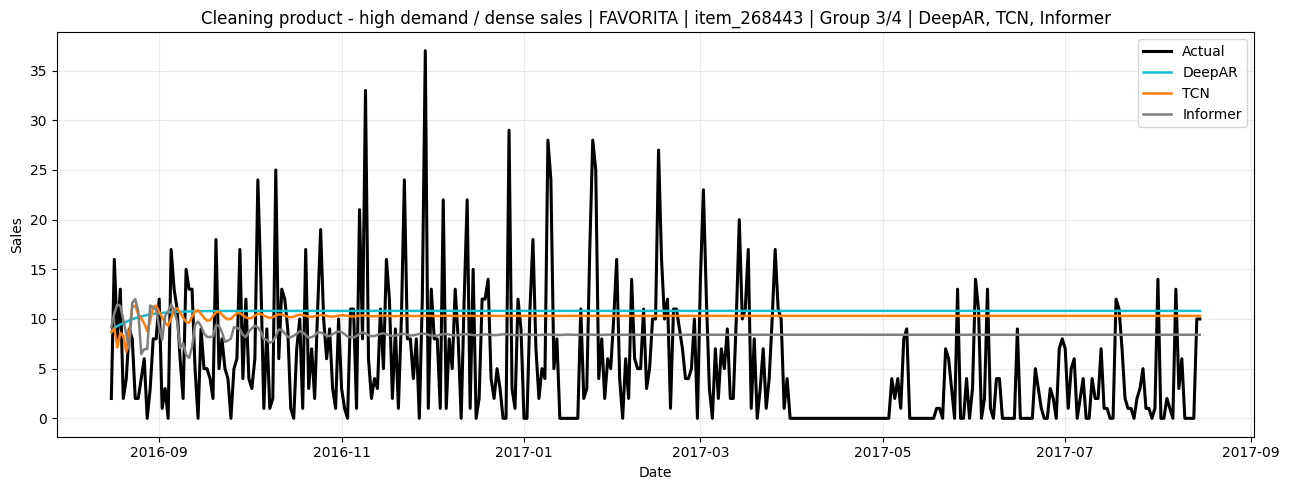

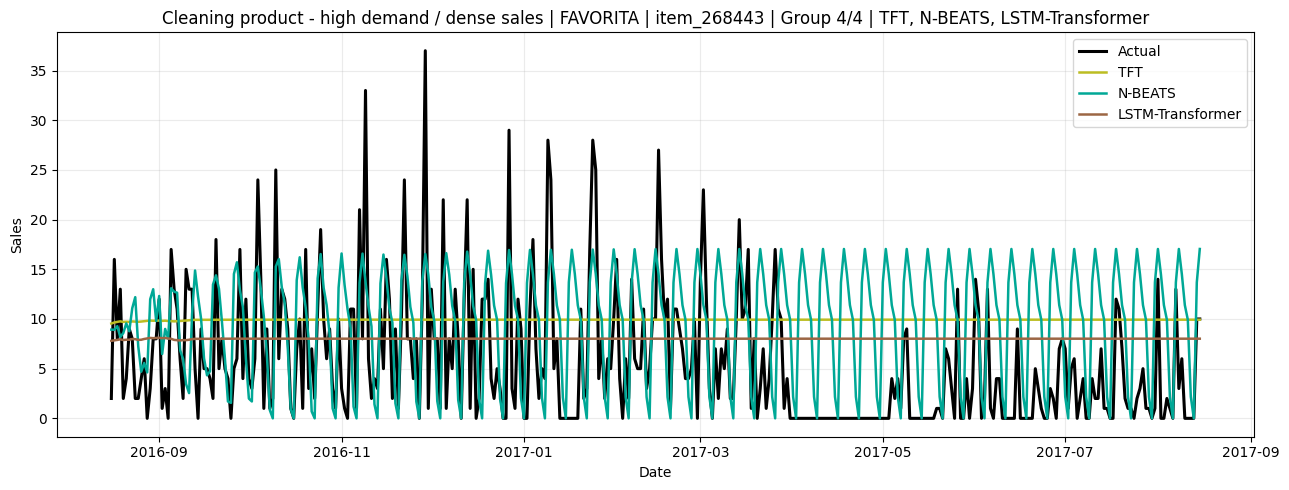

In [14]:
case_index = 0
case = experiment_cases[case_index]
case_rows = [r for r in results if r['dataset'] == case['dataset'] and r['series_id'] == case['series_id']]

if not case_rows:
    raise ValueError('No results found for the selected case_index.')

models_per_chart = 3
plot_groups = [
    ['SARIMAX', 'HURDLE', 'TSB'],
    ['CROSTON_SBA', 'LSTM', 'GRU'],
    ['DeepAR', 'TCN', 'Informer'],
    ['TFT', 'N-BEATS', 'LSTM-Transformer'],
]
row_map = {row['model']: row for row in case_rows}
case_chunks = []
for group in plot_groups:
    chunk_rows = [row_map[m] for m in group if m in row_map]
    if chunk_rows:
        case_chunks.append((group, chunk_rows))

remaining_rows = [row for row in case_rows if row['model'] not in {m for g in plot_groups for m in g}]
for i in range(0, len(remaining_rows), models_per_chart):
    extra_rows = remaining_rows[i:i + models_per_chart]
    if extra_rows:
        case_chunks.append(([row['model'] for row in extra_rows], extra_rows))

if not MATPLOTLIB_AVAILABLE:
    render_case_forecast_svg(case, case_rows, plot_groups=plot_groups, models_per_chart=models_per_chart)
else:
    color_map = {
        'Actual': 'black',
        'SARIMAX': '#1f77b4',
        'HURDLE': '#d62728',
        'TSB': '#2ca02c',
        'CROSTON_SBA': '#8c564b',
        'LSTM': '#9467bd',
        'GRU': '#e377c2',
        'DeepAR': '#17becf',
        'TCN': '#ff7f0e',
        'Informer': '#7f7f7f',
        'TFT': '#bcbd22',
        'N-BEATS': '#00a896',
        'LSTM-Transformer': '#9c6644',
    }

    for chunk_idx, (group_names, chunk_rows) in enumerate(case_chunks, start=1):
        fig, ax = plt.subplots(figsize=(13, 5))
        ax.plot(
            case_rows[0]['test_dates'],
            case_rows[0]['y_test'],
            label='Actual',
            color=color_map['Actual'],
            linewidth=2.2,
        )

        for row in chunk_rows:
            ax.plot(
                row['test_dates'],
                row['y_pred'],
                label=row['model'],
                color=color_map.get(row['model']),
                linewidth=1.8,
            )

        ax.set_title(
            f"{case['semantic_product']} | {case['dataset']} | {case['series_id']} | Group {chunk_idx}/{len(case_chunks)} | {', '.join(group_names)}"
        )
        ax.set_xlabel('Date')
        ax.set_ylabel('Sales')
        ax.legend(loc='upper right')
        ax.grid(alpha=0.25)
        plt.tight_layout()
        display(fig)
        plt.close(fig)


## Comparison Table For One Case

In [15]:
case_index = 0
case = experiment_cases[case_index]
case_rows = [r for r in results if r['dataset'] == case['dataset'] and r['series_id'] == case['series_id']]

if not case_rows:
    raise ValueError('No results found for the selected case_index.')

case_rows_df = pd.DataFrame([
    {k: v for k, v in row.items() if k not in ['y_test', 'y_pred', 'conf_low', 'conf_up', 'test_dates']}
    for row in case_rows
])

plot_groups = [
    ['SARIMAX', 'HURDLE', 'TSB'],
    ['CROSTON_SBA', 'LSTM', 'GRU'],
    ['DeepAR', 'TCN', 'Informer'],
    ['TFT', 'N-BEATS', 'LSTM-Transformer'],
]
included_models = {model for group in plot_groups for model in group}

best_observed_row = case_rows_df.sort_values(['mae', 'rmse']).iloc[0]
best_observed_model = best_observed_row['model']

strong_baselines_df = case_rows_df[case_rows_df['model_group'] == 'existing_strong_baseline'].sort_values(['mae', 'rmse'])
if not strong_baselines_df.empty:
    engine_selected_model = strong_baselines_df.iloc[0]['model']
    engine_reason_text = 'Best existing strong baseline for this case under the regime-switching view.'
else:
    engine_selected_model = best_observed_model
    engine_reason_text = 'Fallback to the best observed model because no existing strong baseline was available.'

model_purpose_map = {
    'SARIMAX': 'Baseline for dense or relatively stable demand with temporal structure.',
    'HURDLE': 'Separates sale occurrence from sale size; useful for zero-heavy demand.',
    'CROSTON_SBA': 'Classic intermittent-demand baseline using Croston-style updates.',
    'TSB': 'Specialized model for intermittent demand with probability-and-size smoothing.',
    'LSTM': 'Recurrent deep challenger for nonlinear temporal dependencies.',
    'GRU': 'Compact recurrent deep challenger with lower parameter cost than LSTM.',
    'DeepAR': 'Probabilistic autoregressive deep challenger for sequential forecasting.',
    'TCN': 'Convolutional sequence challenger with dilated temporal filters.',
    'Informer': 'Transformer-style challenger for longer-range sequence patterns.',
    'TFT': 'Temporal Fusion Transformer style challenger with attention and gating.',
    'N-BEATS': 'Residual block deep challenger focused on flexible univariate forecasting.',
    'LSTM-Transformer': 'Hybrid recurrent-attention challenger combining memory and attention.',
}

comparison_rows = []
for model_name in BENCHMARK_MODEL_NAMES:
    model_df = case_rows_df[case_rows_df['model'] == model_name]
    if model_df.empty:
        continue
    row = model_df.iloc[0]
    is_best_observed = model_name == best_observed_model
    is_engine_selected = model_name == engine_selected_model
    comparison_rows.append({
        'model': model_name,
        'included_in_plot': 'Yes' if model_name in included_models else 'No',
        'best_observed_for_case': 'Yes' if is_best_observed else 'No',
        'engine_recommended': 'Yes' if is_engine_selected else 'No',
        'why_included': model_purpose_map.get(model_name, 'Included as part of the benchmark challenger set.'),
        'why_selected': (
            'Best observed model for this case based on MAE, with RMSE used as tie-breaker.'
            if is_best_observed
            else f'Not selected: ranked below {best_observed_model} on case-level benchmark error.'
        ),
        'engine_reason': (
            engine_reason_text
            if is_engine_selected
            else f'Engine preferred {engine_selected_model} for this case.'
        ),
        'detected_regime': row.get('sbc_regime_train', row.get('expected_regime')),
        'zero_rate': round(float(row.get('zero_rate_train', np.nan)), 3) if pd.notna(row.get('zero_rate_train', np.nan)) else np.nan,
        'ADI': round(float(row.get('ADI_train', np.nan)), 2) if pd.notna(row.get('ADI_train', np.nan)) else np.nan,
        'CV2': round(float(row.get('CV2_train', np.nan)), 3) if pd.notna(row.get('CV2_train', np.nan)) else np.nan,
        'MAE': round(float(row['mae']), 4),
        'RMSE': round(float(row['rmse']), 4),
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)


,model,included_in_plot,best_observed_for_case,engine_recommended,why_included,why_selected,engine_reason,detected_regime,zero_rate,ADI,CV2,MAE,RMSE
0,SARIMAX,Yes,No,No,Baseline for dense or relatively stable demand...,Not selected: ranked below HURDLE on case-leve...,Engine preferred HURDLE for this case.,erratic,0.148,1.17,0.643,3.6723,5.4912
1,HURDLE,Yes,Yes,Yes,Separates sale occurrence from sale size; usef...,Best observed model for this case based on MAE...,Best existing strong baseline for this case un...,erratic,0.148,1.17,0.643,2.9282,4.8073
2,TSB,Yes,No,No,Specialized model for intermittent demand with...,Not selected: ranked below HURDLE on case-leve...,Engine preferred HURDLE for this case.,erratic,0.148,1.17,0.643,5.3850,6.6152
3,CROSTON_SBA,Yes,No,No,Classic intermittent-demand baseline using Cro...,Not selected: ranked below HURDLE on case-leve...,Engine preferred HURDLE for this case.,erratic,0.148,1.17,0.643,5.5172,6.6968
4,LSTM,Yes,No,No,Recurrent deep challenger for nonlinear tempor...,Not selected: ranked below HURDLE on case-leve...,Engine preferred HURDLE for this case.,erratic,0.148,1.17,0.643,7.0262,8.0707
5,GRU,Yes,No,No,Compact recurrent deep challenger with lower p...,Not selected: ranked below HURDLE on case-leve...,Engine preferred HURDLE for this case.,erratic,0.148,1.17,0.643,7.0818,8.1267
6,DeepAR,Yes,No,No,Probabilistic autoregressive deep challenger f...,Not selected: ranked below HURDLE on case-leve...,Engine preferred HURDLE for this case.,erratic,0.148,1.17,0.643,7.2409,8.2874
7,TCN,Yes,No,No,Convolutional sequence challenger with dilated...,Not selected: ranked below HURDLE on case-leve...,Engine preferred HURDLE for this case.,erratic,0.148,1.17,0.643,6.9352,7.9799
8,Informer,Yes,No,No,Transformer-style challenger for longer-range ...,Not selected: ranked below HURDLE on case-leve...,Engine preferred HURDLE for this case.,erratic,0.148,1.17,0.643,6.0238,7.0941
9,TFT,Yes,No,No,Temporal Fusion Transformer style challenger w...,Not selected: ranked below HURDLE on case-leve...,Engine preferred HURDLE for this case.,erratic,0.148,1.17,0.643,6.7330,7.7829


## Simple Three-Product Summary

In [16]:
SELECTED_SIMPLE_CASES = [
    {
        'series_id': 'item_268443',
        'selection_role': 'normal demand',
    },
    {
        'series_id': 'B0BZTL57BP',
        'selection_role': 'intermittent demand',
    },
    {
        'series_id': 'item_789224',
        'selection_role': 'erratic demand',
    },
]
SELECTED_SIMPLE_CASE_IDS = [item['series_id'] for item in SELECTED_SIMPLE_CASES]

status_order = {'Good': 0, 'Questionable': 1, 'Poor': 2}
regime_model_groups = {'existing_strong_baseline', 'existing_reference_baseline'}

def build_results_df_for_simple_tables():
    if 'results' in globals() and isinstance(results, list) and len(results) > 0:
        result_rows = [
            {k: v for k, v in row.items() if k not in ['y_test', 'y_pred', 'conf_low', 'conf_up', 'test_dates']}
            for row in results
        ]
        working_df = pd.DataFrame(result_rows)
    elif 'results_df' in globals() and isinstance(results_df, pd.DataFrame):
        working_df = results_df.copy()
    else:
        return pd.DataFrame()

    for col in ['peak_detection_rate', 'variance_ratio', 'shape_similarity', 'direction_accuracy']:
        if col not in working_df.columns:
            working_df[col] = np.nan

    if 'model_group' not in working_df.columns:
        model_group_map = {
            'SARIMAX': 'existing_strong_baseline',
            'HURDLE': 'existing_strong_baseline',
            'TSB': 'existing_reference_baseline',
            'CROSTON_SBA': 'existing_reference_baseline',
            'LSTM': 'challenger_model',
            'GRU': 'challenger_model',
            'DeepAR': 'challenger_model',
            'TCN': 'challenger_model',
            'Informer': 'challenger_model',
            'TFT': 'challenger_model',
            'N-BEATS': 'challenger_model',
            'LSTM-Transformer': 'challenger_model',
        }
        working_df['model_group'] = working_df['model'].map(model_group_map).fillna('challenger_model')

    return working_df

def vr_closeness(vr):
    if pd.isna(vr):
        return 0.0
    return max(0.0, 1.0 - abs(float(vr) - 1.0))

def peak_behavior_status_from_row(row):
    pdr = float(row.get('peak_detection_rate', np.nan)) if pd.notna(row.get('peak_detection_rate', np.nan)) else np.nan
    vr = float(row.get('variance_ratio', np.nan)) if pd.notna(row.get('variance_ratio', np.nan)) else np.nan
    shape = float(row.get('shape_similarity', np.nan)) if pd.notna(row.get('shape_similarity', np.nan)) else np.nan
    direction = float(row.get('direction_accuracy', np.nan)) if pd.notna(row.get('direction_accuracy', np.nan)) else np.nan
    if (pd.notna(pdr) and pdr < 0.50) or (pd.notna(vr) and (vr < 0.60 or vr > 1.50)) or (pd.notna(shape) and shape < 0.60):
        return 'Poor'
    if (pd.notna(pdr) and pdr < 0.75) or (pd.notna(vr) and (vr < 0.75 or vr > 1.25)) or (pd.notna(direction) and direction < 0.50):
        return 'Questionable'
    return 'Good'

def behavioral_score_from_row(row):
    pdr = float(row.get('peak_detection_rate', 0.0)) if pd.notna(row.get('peak_detection_rate', np.nan)) else 0.0
    vr_score = vr_closeness(row.get('variance_ratio', np.nan))
    shape = float(row.get('shape_similarity', 0.0)) if pd.notna(row.get('shape_similarity', np.nan)) else 0.0
    direction = float(row.get('direction_accuracy', 0.0)) if pd.notna(row.get('direction_accuracy', np.nan)) else 0.0
    mae_penalty = 1.0 / (1.0 + float(row.get('mae', 0.0)))
    return 0.40 * pdr + 0.20 * vr_score + 0.20 * shape + 0.10 * direction + 0.10 * mae_penalty

def metric_or_na(row, key, decimals=3):
    value = row.get(key, np.nan)
    if pd.isna(value):
        return 'N/A'
    return f"{float(value):.{decimals}f}"

def overfit_assessment_text(best_row, best_mae_model):
    has_behavioral_metrics = any(pd.notna(best_row.get(col, np.nan)) for col in ['peak_detection_rate', 'variance_ratio', 'shape_similarity', 'direction_accuracy'])
    if not has_behavioral_metrics:
        return 'Behavioral metrics were not stored in this results run, so overfitting cannot be judged from peak behavior yet. Re-run the benchmark to populate those fields.'
    if best_row['model'] == best_mae_model and best_row['peak_behavior_status'] == 'Good':
        return 'No clear overfitting signal from test behavior, but this is not a formal overfitting test because train-vs-validation gaps were not stored.'
    if best_row['peak_behavior_status'] != 'Good':
        return 'Possible overfitting or miscalibration signal: the model may look favorable on average error but does not reproduce peaks/variability well on the test period.'
    return 'No obvious overfitting signal for the selected model, but formal confirmation would require train/validation error tracking.'

def why_best_text(best_row):
    has_behavioral_metrics = any(pd.notna(best_row.get(col, np.nan)) for col in ['peak_detection_rate', 'variance_ratio', 'shape_similarity'])
    if not has_behavioral_metrics:
        return (
            f"Selected as best observed based on the currently available results fields "
            f"(MAE={metric_or_na(best_row, 'mae', 4)}, RMSE={metric_or_na(best_row, 'rmse', 4)}). "
            f"Behavioral metrics for peaks and shape are not available in this run yet."
        )
    return (
        f"Selected as best observed because it balanced average error and demand behavior better than the other models "
        f"(MAE={metric_or_na(best_row, 'mae', 4)}, RMSE={metric_or_na(best_row, 'rmse', 4)}, PDR={metric_or_na(best_row, 'peak_detection_rate')}, "
        f"VR={metric_or_na(best_row, 'variance_ratio')}, Shape={metric_or_na(best_row, 'shape_similarity')})."
    )

def regime_better_text(regime_best_row, challenger_best_row):
    if challenger_best_row is None:
        return f"Yes. Only regime-oriented models were available for comparison; the best one was {regime_best_row['model']}."
    if regime_best_row['behavioral_score'] >= challenger_best_row['behavioral_score']:
        return (
            f"Yes. The best regime-oriented model ({regime_best_row['model']}) matched or beat the best challenger "
            f"({challenger_best_row['model']}) on behavioral score for this product."
        )
    return (
        f"No. A challenger model ({challenger_best_row['model']}) beat the best regime-oriented model "
        f"({regime_best_row['model']}) on behavioral score for this product."
    )

def compact_model_results(group_df):
    ordered = group_df.sort_values(['status_order', 'behavioral_score', 'mae'], ascending=[True, False, True])
    lines = []
    for _, row in ordered.iterrows():
        lines.append(
            f"{row['model']}: MAE={metric_or_na(row, 'mae', 4)}, RMSE={metric_or_na(row, 'rmse', 4)}, "
            f"PDR={metric_or_na(row, 'peak_detection_rate')}, VR={metric_or_na(row, 'variance_ratio')}, "
            f"Shape={metric_or_na(row, 'shape_similarity')}, Status={row['peak_behavior_status']}"
        )
    return '\n'.join(lines)


In [17]:
selected_case_rows = []
for selected_case in SELECTED_SIMPLE_CASES:
    case_matches = [c for c in experiment_cases if c['series_id'] == selected_case['series_id']]
    if not case_matches:
        continue
    case = case_matches[0]
    selected_case_rows.append({
        'selected_as': selected_case['selection_role'],
        'dataset': case['dataset'],
        'series_id': case['series_id'],
        'semantic_product': case['semantic_product'],
        'expected_regime': case['expected_regime'],
    })
selected_cases_df = pd.DataFrame(selected_case_rows)
display(selected_cases_df)


,selected_as,dataset,series_id,semantic_product,expected_regime
0,normal demand,FAVORITA,item_268443,Cleaning product - high demand / dense sales,high-demand
1,intermittent demand,AMAZON_2023,B0BZTL57BP,Household hygiene - intermittent demand,intermittent
2,erratic demand,FAVORITA,item_789224,Cleaning product - erratic transition case,erratic


In [18]:
simple_rows = []

working_results_df = build_results_df_for_simple_tables()
selected_results_df = working_results_df[working_results_df['series_id'].isin(SELECTED_SIMPLE_CASE_IDS)].copy()
if selected_results_df.empty:
    print('No selected-product results are available yet. Run the benchmark cell first so results can be collected.')
    display(selected_results_df)
else:
    selected_results_df['peak_behavior_status'] = selected_results_df.apply(peak_behavior_status_from_row, axis=1)
    selected_results_df['behavioral_score'] = selected_results_df.apply(behavioral_score_from_row, axis=1)
    selected_results_df['status_order'] = selected_results_df['peak_behavior_status'].map(status_order)

    for selected_case in SELECTED_SIMPLE_CASES:
        series_id = selected_case['series_id']
        grp = selected_results_df[selected_results_df['series_id'] == series_id].copy()
        if grp.empty:
            continue
        grp = grp.sort_values(['status_order', 'behavioral_score', 'mae'], ascending=[True, False, True])
        best_observed_row = grp.iloc[0]
        best_mae_row = grp.sort_values(['mae', 'rmse']).iloc[0]
        regime_grp = grp[grp['model_group'].isin(regime_model_groups)].sort_values(['status_order', 'behavioral_score', 'mae'], ascending=[True, False, True])
        challenger_grp = grp[grp['model_group'] == 'challenger_model'].sort_values(['status_order', 'behavioral_score', 'mae'], ascending=[True, False, True])
        regime_best_row = regime_grp.iloc[0] if not regime_grp.empty else None
        challenger_best_row = challenger_grp.iloc[0] if not challenger_grp.empty else None

        simple_rows.append({
            'selected_as': selected_case['selection_role'],
            'product_case': f"{best_observed_row['dataset']} | {best_observed_row['series_id']} | {best_observed_row['semantic_product']}",
            'demand_type': best_observed_row['expected_regime'],
            'models_evaluated': ', '.join(grp['model'].tolist()),
            'all_model_results': compact_model_results(grp),
            'best_model': best_observed_row['model'],
            'best_average_error_model': best_mae_row['model'],
            'why_best': why_best_text(best_observed_row),
            'overfit_assessment': overfit_assessment_text(best_observed_row, best_mae_row['model']),
            'regime_better': regime_better_text(regime_best_row, challenger_best_row) if regime_best_row is not None else 'No regime-oriented model available.',
        })

    simple_summary_df = pd.DataFrame(simple_rows)
    display(simple_summary_df)


,selected_as,product_case,demand_type,models_evaluated,all_model_results,best_model,best_average_error_model,why_best,overfit_assessment,regime_better
0,normal demand,FAVORITA | item_268443 | Cleaning product - hi...,high-demand,"HURDLE, SARIMAX, TSB, CROSTON_SBA, LSTM-Transf...","HURDLE: MAE=2.9282, RMSE=4.8073, PDR=N/A, VR=N...",HURDLE,HURDLE,Selected as best observed based on the current...,Behavioral metrics were not stored in this res...,Yes. The best regime-oriented model (HURDLE) m...
1,intermittent demand,AMAZON_2023 | B0BZTL57BP | Household hygiene -...,intermittent,"LSTM-Transformer, TSB, CROSTON_SBA, Informer, ...","LSTM-Transformer: MAE=0.0356, RMSE=0.1887, PDR...",LSTM-Transformer,LSTM-Transformer,Selected as best observed based on the current...,Behavioral metrics were not stored in this res...,No. A challenger model (LSTM-Transformer) beat...
2,erratic demand,FAVORITA | item_789224 | Cleaning product - er...,erratic,"HURDLE, SARIMAX, CROSTON_SBA, TSB, GRU, Inform...","HURDLE: MAE=2.2389, RMSE=3.2287, PDR=N/A, VR=N...",HURDLE,HURDLE,Selected as best observed based on the current...,Behavioral metrics were not stored in this res...,Yes. The best regime-oriented model (HURDLE) m...


In [19]:
working_results_df = build_results_df_for_simple_tables()
selected_results_df = working_results_df[working_results_df['series_id'].isin(SELECTED_SIMPLE_CASE_IDS)].copy()
if selected_results_df.empty:
    print('No selected-product results are available yet. Run the benchmark cell first so results can be collected.')
    display(selected_results_df)
else:
    mae_table_df = selected_results_df.pivot(index=['dataset', 'series_id', 'semantic_product'], columns='model', values='mae').reset_index()
    display(mae_table_df)


model,dataset,series_id,semantic_product,CROSTON_SBA,DeepAR,GRU,HURDLE,Informer,LSTM,LSTM-Transformer,N-BEATS,SARIMAX,TCN,TFT,TSB
0,AMAZON_2023,B0BZTL57BP,Household hygiene - intermittent demand,0.069660,0.118104,0.090817,0.116015,0.078380,0.090260,0.035616,0.139824,0.095198,0.081220,0.106556,0.043308
1,FAVORITA,item_268443,Cleaning product - high demand / dense sales,5.517206,7.240891,7.081823,2.928161,6.023769,7.026158,5.807660,6.478692,3.672320,6.935202,6.732994,5.384960
2,FAVORITA,item_789224,Cleaning product - erratic transition case,2.802934,3.376889,3.197238,2.238927,3.300284,3.599184,4.990999,4.995661,2.356789,3.405078,4.431089,2.921688


In [20]:
working_results_df = build_results_df_for_simple_tables()
selected_results_df = working_results_df[working_results_df['series_id'].isin(SELECTED_SIMPLE_CASE_IDS)].copy()
if selected_results_df.empty:
    print('No selected-product results are available yet. Run the benchmark cell first so results can be collected.')
    display(selected_results_df)
else:
    rmse_table_df = selected_results_df.pivot(index=['dataset', 'series_id', 'semantic_product'], columns='model', values='rmse').reset_index()
    display(rmse_table_df)


model,dataset,series_id,semantic_product,CROSTON_SBA,DeepAR,GRU,HURDLE,Informer,LSTM,LSTM-Transformer,N-BEATS,SARIMAX,TCN,TFT,TSB
0,AMAZON_2023,B0BZTL57BP,Household hygiene - intermittent demand,0.185335,0.192818,0.186862,0.246580,0.185611,0.186782,0.188723,0.201912,0.216412,0.185970,0.189762,0.187337
1,FAVORITA,item_268443,Cleaning product - high demand / dense sales,6.696837,8.287359,8.126735,4.807279,7.094073,8.070653,6.927238,8.225187,5.491167,7.979876,7.782945,6.615152
2,FAVORITA,item_789224,Cleaning product - erratic transition case,3.715720,4.612999,4.219582,3.228700,4.509068,4.861172,5.702032,5.801994,3.238221,4.201795,5.677205,3.761511


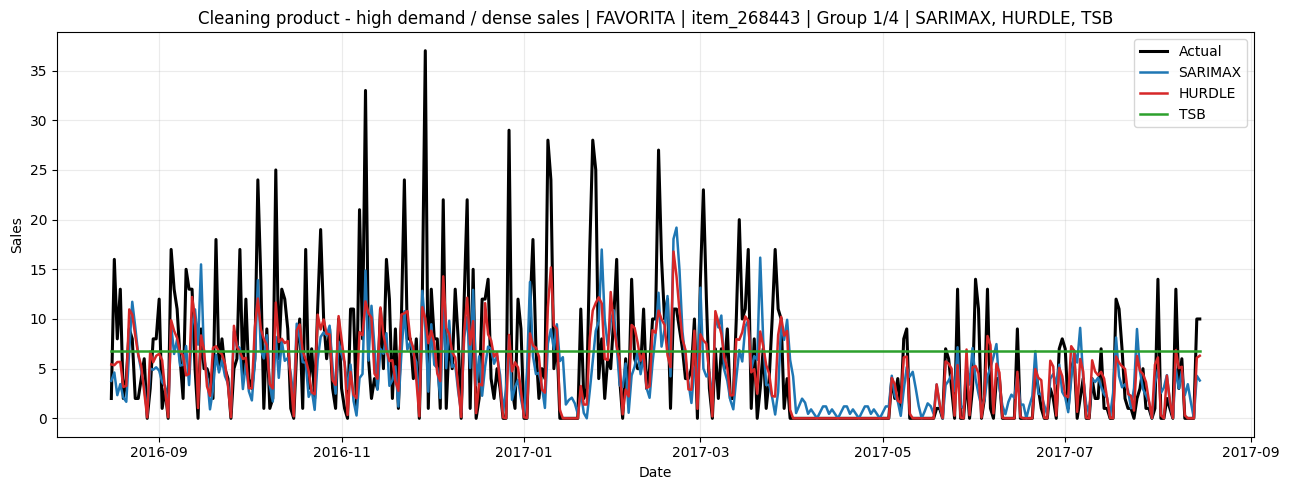

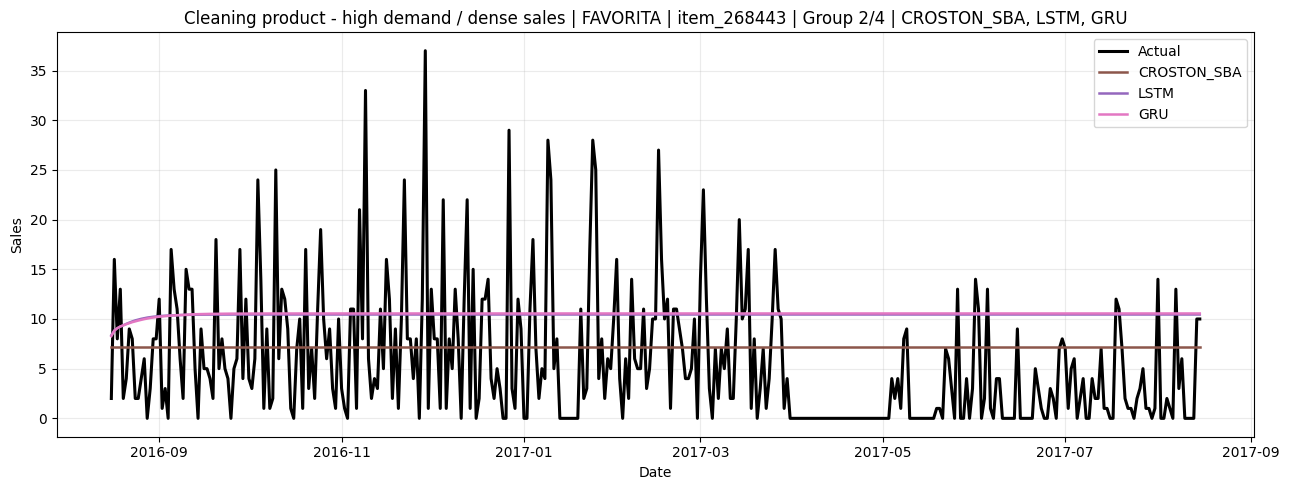

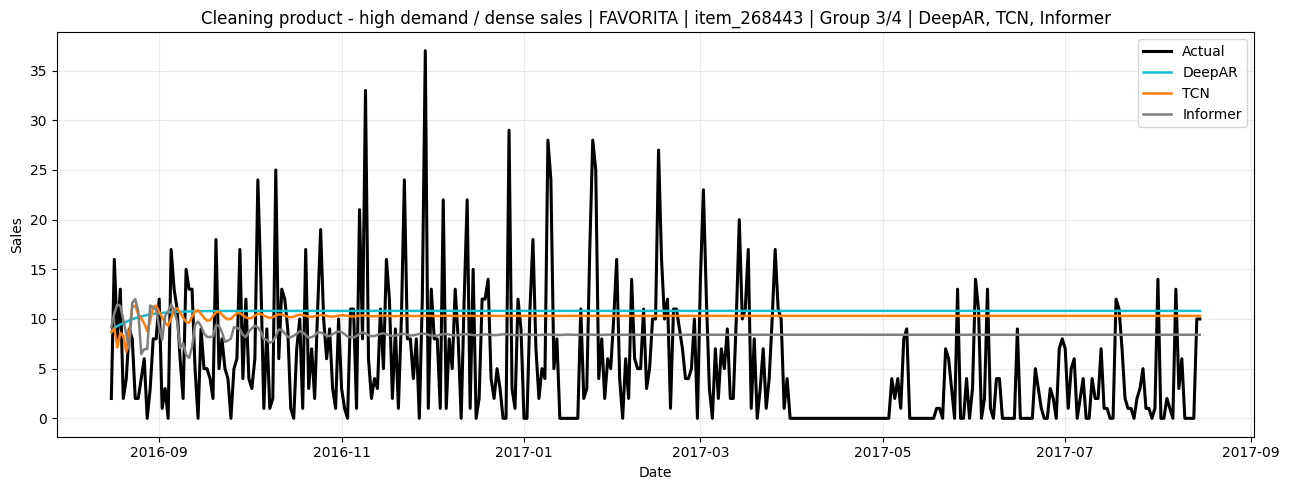

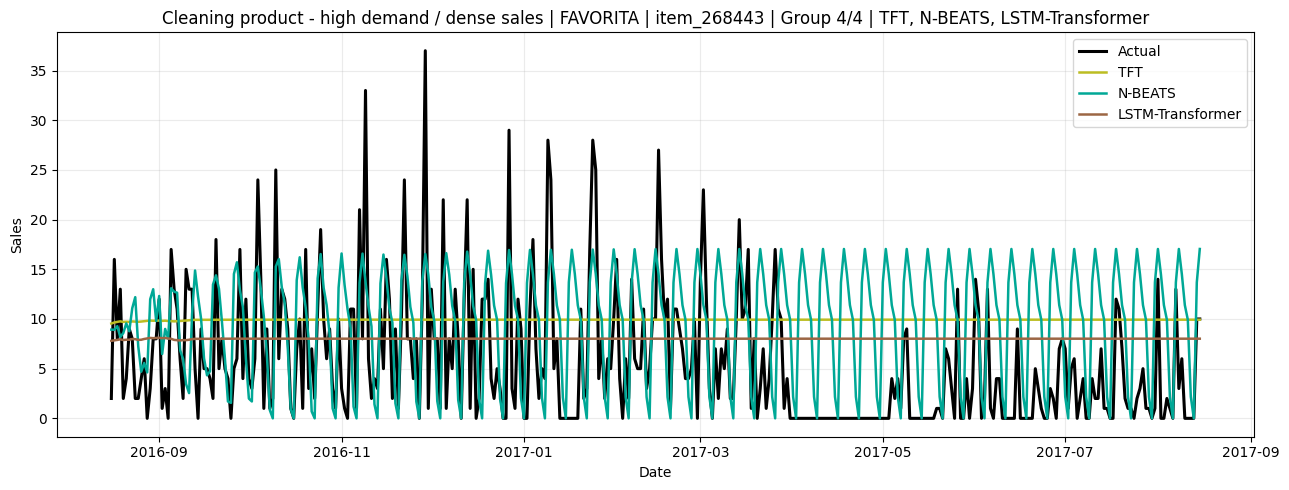

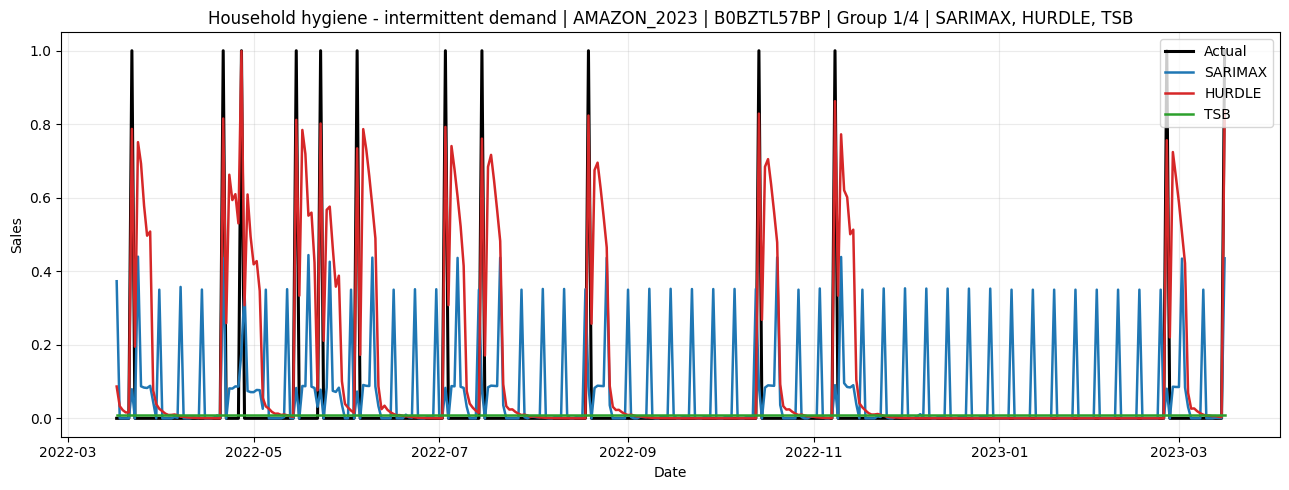

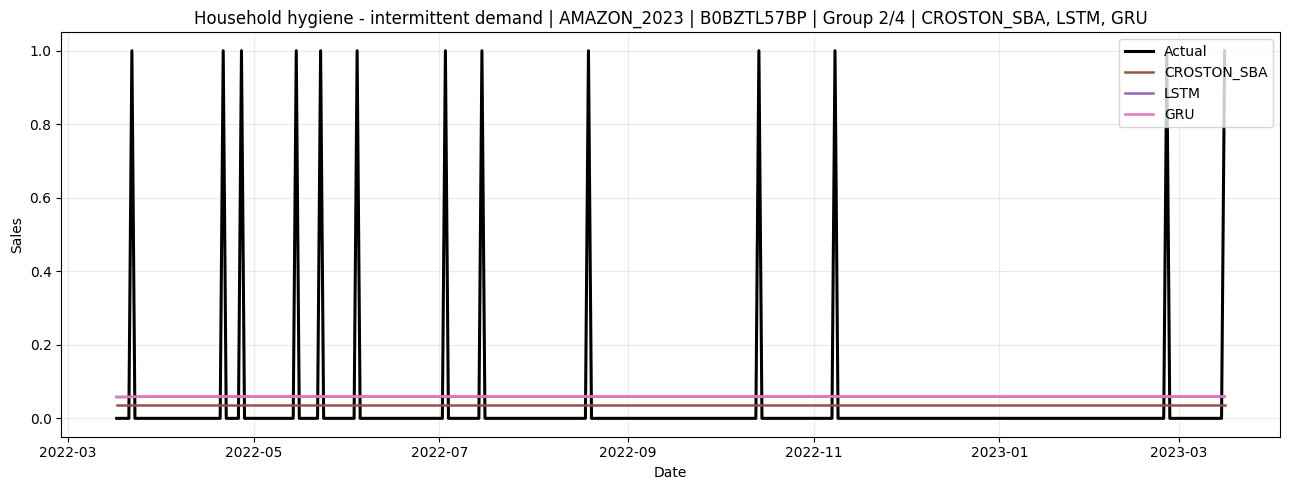

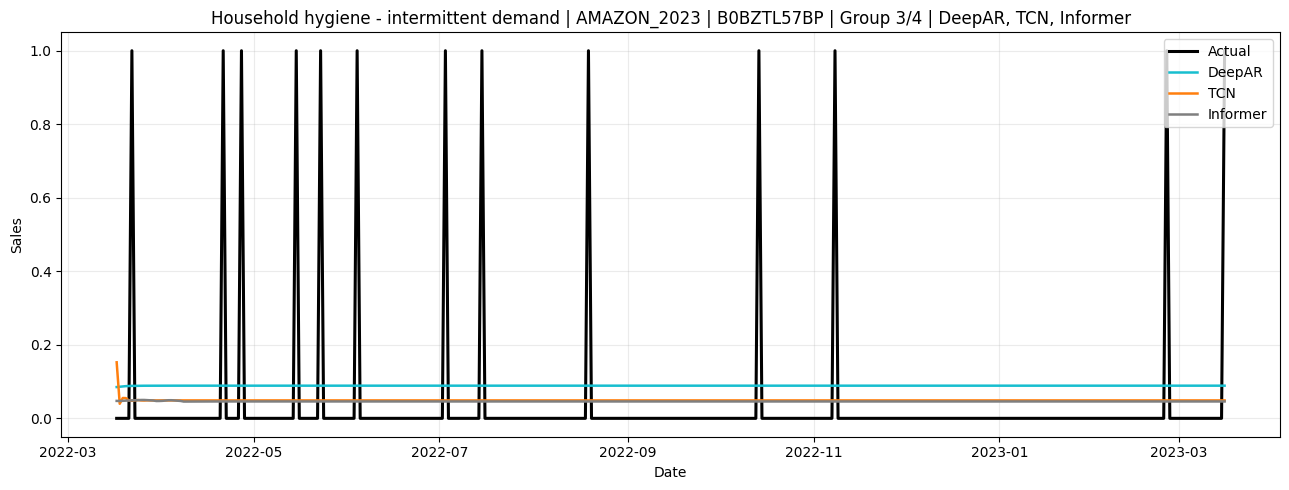

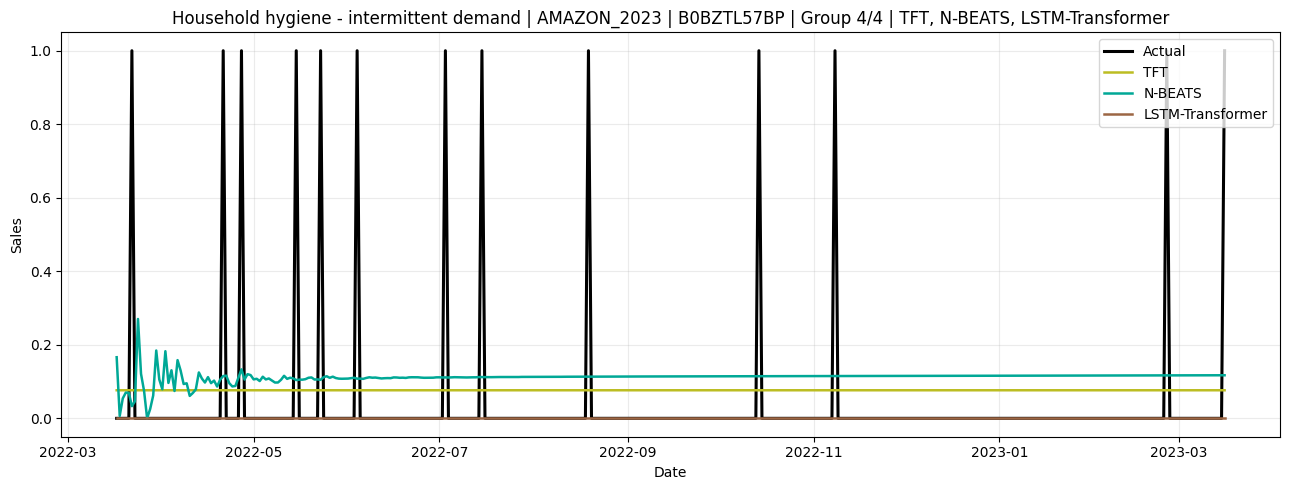

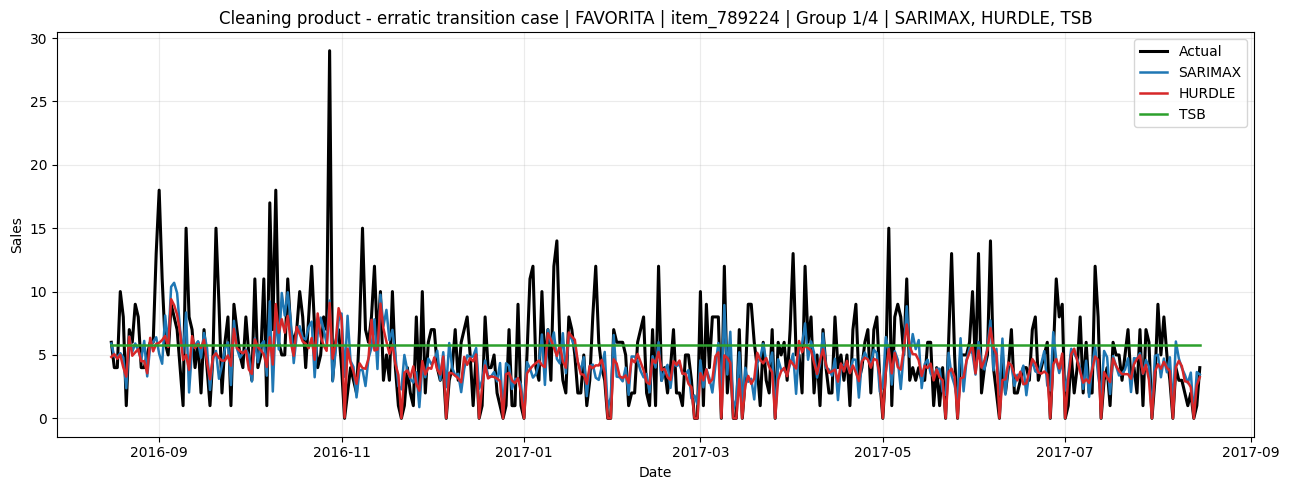

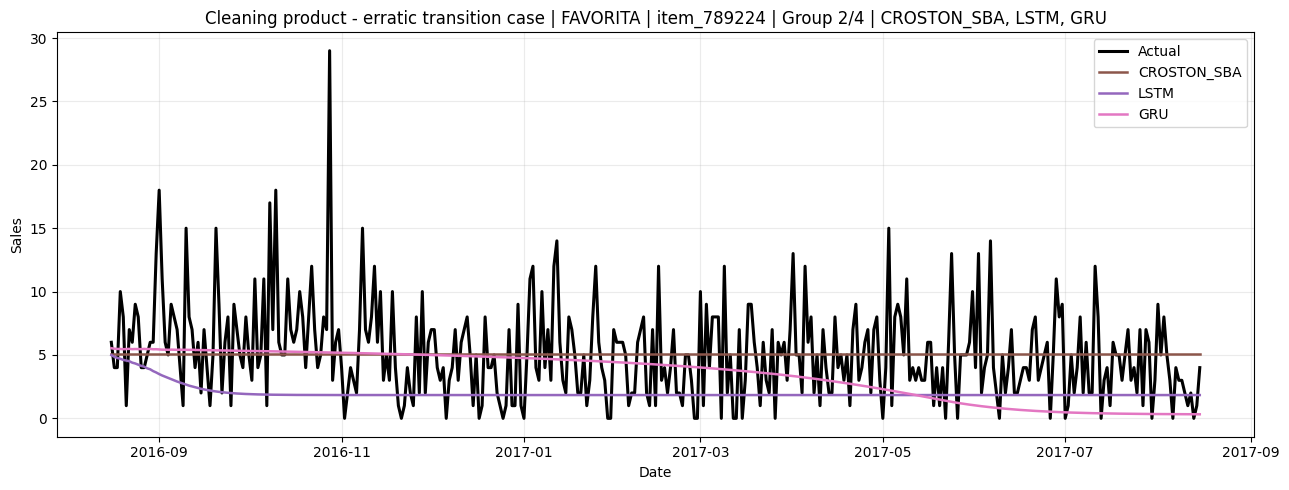

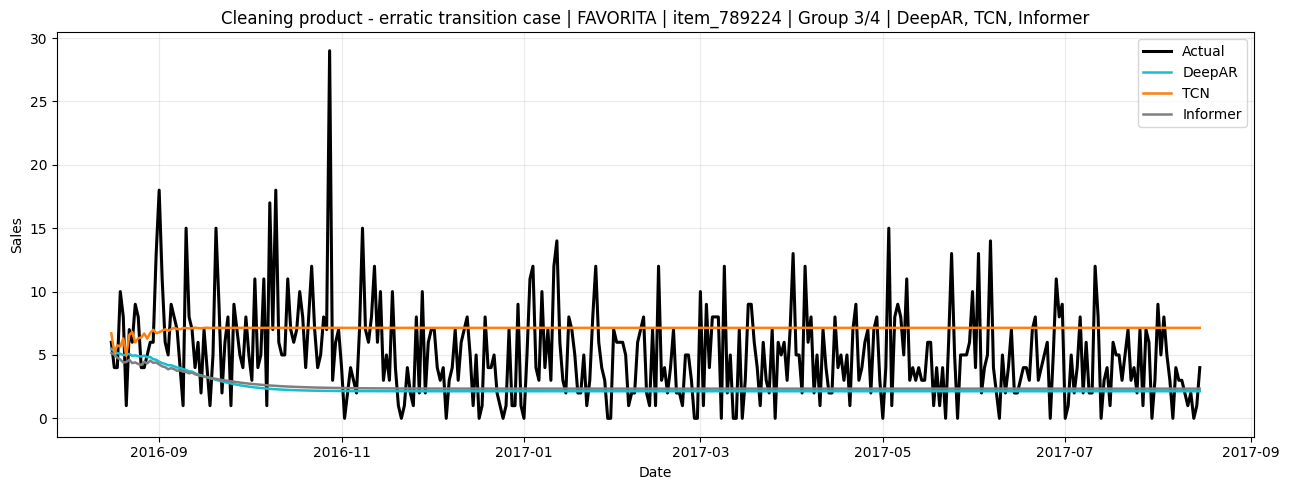

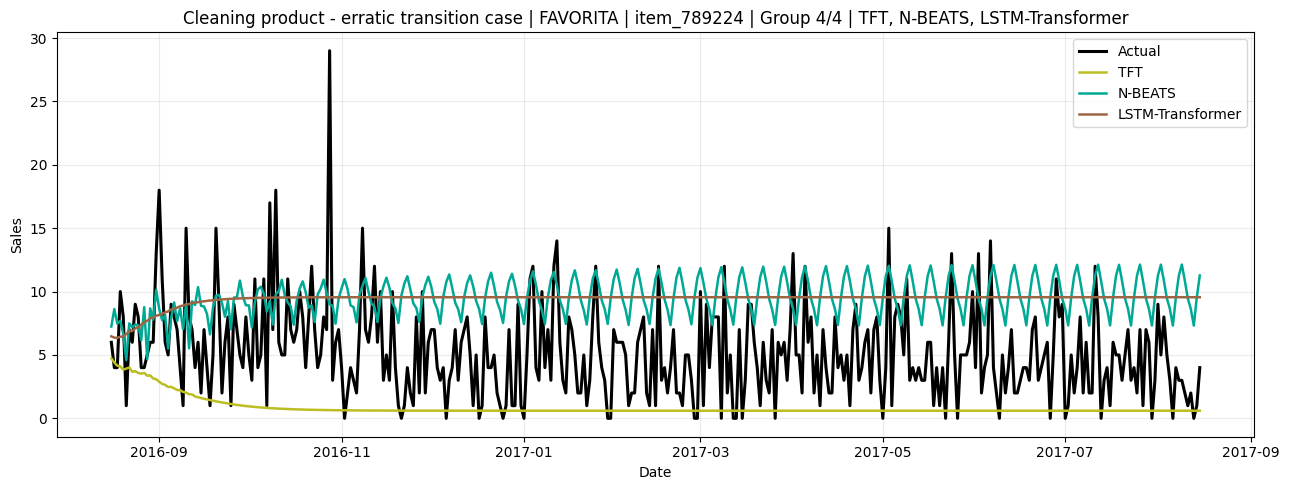

In [21]:
plot_groups = [
    ['SARIMAX', 'HURDLE', 'TSB'],
    ['CROSTON_SBA', 'LSTM', 'GRU'],
    ['DeepAR', 'TCN', 'Informer'],
    ['TFT', 'N-BEATS', 'LSTM-Transformer'],
]

for case_number, selected_case in enumerate(SELECTED_SIMPLE_CASES, start=1):
    series_id = selected_case['series_id']
    case_matches = [c for c in experiment_cases if c['series_id'] == series_id]
    if not case_matches:
        print(f'Case not found for {series_id}')
        continue
    case = case_matches[0]
    case_rows = [r for r in results if r['dataset'] == case['dataset'] and r['series_id'] == case['series_id']]
    if not case_rows:
        print(f"No results found for {case['dataset']} | {case['series_id']}")
        continue
    display(HTML(
        "<hr style='margin-top:30px; margin-bottom:22px; border:0; border-top:2px solid #bbb;'/>"
    ))
    display(HTML(
        f"<div style='font-size:15px; font-weight:600; color:#666; margin-bottom:6px;'>"
        f"Product {case_number}"
        f"</div>"
        f"<h2 style='margin-top:8px; margin-bottom:8px;'>"
        f"{case['semantic_product']}"
        f"</h2>"
        f"<div style='margin-bottom:14px; color:#555;'>"
        f"Selected as: <b>{selected_case['selection_role']}</b> | Dataset: <b>{case['dataset']}</b> | Series: <b>{case['series_id']}</b> | Demand type: <b>{case['expected_regime']}</b>"
        f"</div>"
    ))
    if not MATPLOTLIB_AVAILABLE:
        render_case_forecast_svg(case, case_rows, plot_groups=plot_groups, models_per_chart=3)
    else:
        color_map = {
            'Actual': 'black',
            'SARIMAX': '#1f77b4',
            'HURDLE': '#d62728',
            'TSB': '#2ca02c',
            'CROSTON_SBA': '#8c564b',
            'LSTM': '#9467bd',
            'GRU': '#e377c2',
            'DeepAR': '#17becf',
            'TCN': '#ff7f0e',
            'Informer': '#7f7f7f',
            'TFT': '#bcbd22',
            'N-BEATS': '#00a896',
            'LSTM-Transformer': '#9c6644',
        }
        row_map = {row['model']: row for row in case_rows}
        case_chunks = []
        for group in plot_groups:
            chunk_rows = [row_map[m] for m in group if m in row_map]
            if chunk_rows:
                case_chunks.append((group, chunk_rows))
        remaining_rows = [row for row in case_rows if row['model'] not in {m for g in plot_groups for m in g}]
        for i in range(0, len(remaining_rows), 3):
            extra_rows = remaining_rows[i:i + 3]
            if extra_rows:
                case_chunks.append(([row['model'] for row in extra_rows], extra_rows))
        for chunk_idx, (group_names, chunk_rows) in enumerate(case_chunks, start=1):
            fig, ax = plt.subplots(figsize=(13, 5))
            ax.plot(
                case_rows[0]['test_dates'],
                case_rows[0]['y_test'],
                label='Actual',
                color=color_map['Actual'],
                linewidth=2.2,
            )
            for row in chunk_rows:
                ax.plot(
                    row['test_dates'],
                    row['y_pred'],
                    label=row['model'],
                    color=color_map.get(row['model']),
                    linewidth=1.8,
                )
            ax.set_title(
                f"{case['semantic_product']} | {case['dataset']} | {case['series_id']} | Group {chunk_idx}/{len(case_chunks)} | {', '.join(group_names)}"
            )
            ax.set_xlabel('Date')
            ax.set_ylabel('Sales')
            ax.legend(loc='upper right')
            ax.grid(alpha=0.25)
            plt.tight_layout()
            display(fig)
            plt.close(fig)


## Behavioral Metrics - PDR and VR for All 12 Models


In [22]:
from scipy.signal import find_peaks

def peak_detection_rate(y_true, y_pred, window=3):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    prominence = max(0.2 * (y_true.max() - y_true.min()), 1e-6)
    true_peaks, _ = find_peaks(y_true, prominence=prominence)
    pred_peaks, _ = find_peaks(y_pred, prominence=prominence * 0.5)
    if len(true_peaks) == 0:
        return np.nan
    detected = sum(
        any(abs(tp - pp) <= window for pp in pred_peaks)
        for tp in true_peaks
    )
    return detected / len(true_peaks)

def variance_ratio(y_true, y_pred):
    sigma_t = float(np.std(y_true))
    sigma_p = float(np.std(y_pred))
    if sigma_t < 1e-9:
        return np.nan
    return sigma_p / sigma_t

def trend_correlation(y_true, y_pred, window=7):
    ma_t = pd.Series(y_true).rolling(window, min_periods=1).mean().values
    ma_p = pd.Series(y_pred).rolling(window, min_periods=1).mean().values
    if np.std(ma_t) < 1e-9 or np.std(ma_p) < 1e-9:
        return np.nan
    return float(np.corrcoef(ma_t, ma_p)[0, 1])

for row in results:
    row['pdr'] = peak_detection_rate(row['y_test'], row['y_pred'])
    row['vr'] = variance_ratio(row['y_test'], row['y_pred'])
    row['trend_corr'] = trend_correlation(row['y_test'], row['y_pred'])

result_rows_with_beh = [
    {k: v for k, v in row.items()
     if k not in ['y_test', 'y_pred', 'conf_low', 'conf_up', 'test_dates']}
    for row in results
]
results_df_beh = pd.DataFrame(result_rows_with_beh)

print('=== Peak Detection Rate (PDR) - higher is better ===')
print('PDR = 0.0 means the model detected ZERO demand spikes')
print('PDR = 1.0 means the model detected ALL demand spikes')
print()
pdr_pivot = results_df_beh.pivot_table(
    index='model', columns='series_id', values='pdr'
).round(3)
display(pdr_pivot)

print()
print('=== Variance Ratio (VR) - closest to 1.0 is best ===')
print('VR << 1.0 means flat forecast (predicting near zero always)')
print('VR ~= 1.0 means correctly calibrated volatility')
print()
vr_pivot = results_df_beh.pivot_table(
    index='model', columns='series_id', values='vr'
).round(3)
display(vr_pivot)


=== Peak Detection Rate (PDR) - higher is better ===
PDR = 0.0 means the model detected ZERO demand spikes
PDR = 1.0 means the model detected ALL demand spikes



series_id,B0BR4W8TBH,B0BZTL57BP,HOUSEHOLD_1_187_WI_1_validation,item_268443,item_789224
model,,,,,
CROSTON_SBA,0.0,0.000,0.000,0.000,0.000
DeepAR,0.0,0.000,0.000,0.000,0.000
GRU,0.0,0.000,0.000,0.000,0.000
HURDLE,1.0,1.000,0.548,0.896,0.500
Informer,0.0,0.000,0.000,0.021,0.000
LSTM,0.0,0.000,0.000,0.000,0.000
LSTM-Transformer,0.0,0.000,0.000,0.000,0.000
N-BEATS,0.0,0.083,0.065,0.979,0.929
SARIMAX,1.0,1.000,0.419,0.854,0.750



=== Variance Ratio (VR) - closest to 1.0 is best ===
VR << 1.0 means flat forecast (predicting near zero always)
VR ~= 1.0 means correctly calibrated volatility



series_id,B0BR4W8TBH,B0BZTL57BP,HOUSEHOLD_1_187_WI_1_validation,item_268443,item_789224
model,,,,,
CROSTON_SBA,0.000,0.000,0.000,0.000,0.000
DeepAR,0.001,0.001,0.002,0.034,0.183
GRU,0.001,0.001,0.015,0.035,0.502
HURDLE,1.141,1.367,1.318,0.580,0.456
Informer,0.003,0.003,0.188,0.094,0.143
LSTM,0.000,0.001,0.002,0.030,0.148
LSTM-Transformer,0.000,0.000,0.001,0.004,0.145
N-BEATS,0.110,0.094,0.232,0.878,0.401
SARIMAX,0.947,0.695,0.362,0.535,0.498


## The MAE Illusion on Intermittent Products


In [23]:
intermittent_df = results_df_beh[
    results_df_beh['zero_rate_train'] >= 0.70
].copy()

key_table = intermittent_df[[
    'series_id', 'model', 'model_group',
    'mae', 'pdr', 'vr', 'trend_corr'
]].sort_values(['series_id', 'mae']).reset_index(drop=True)

key_table['mae_illusion'] = (
    (key_table['mae'] < 0.15) &
    (key_table['pdr'].fillna(0) < 0.10)
).map({True: 'YES - flat forecast wins MAE', False: '-'})

print('=== MAE vs PDR on intermittent products ===')
print('Products with zero_rate >= 0.70 (intermittent regime)')
print()
display(key_table.round({'mae': 4, 'pdr': 3, 'vr': 3, 'trend_corr': 3}))

def format_metric(v, decimals=3):
    return f"{v:.{decimals}f}" if pd.notna(v) else 'NaN'

print()
for sid in intermittent_df['series_id'].unique():
    sub = intermittent_df[intermittent_df['series_id'] == sid]
    best_mae_row = sub.loc[sub['mae'].idxmin()]
    best_pdr_row = sub.loc[sub['pdr'].fillna(0).idxmax()]
    print(f'Product: {sid}')
    print(f"  Best MAE: {best_mae_row['model']:20s}  MAE={best_mae_row['mae']:.4f}  PDR={format_metric(best_mae_row['pdr'])}")
    print(f"  Best PDR: {best_pdr_row['model']:20s}  MAE={best_pdr_row['mae']:.4f}  PDR={format_metric(best_pdr_row['pdr'])}")
    if best_mae_row['model'] != best_pdr_row['model']:
        print(
            f"  *** MAE ILLUSION: '{best_mae_row['model']}' wins MAE but has PDR={format_metric(best_mae_row['pdr'])} (detects no spikes). '{best_pdr_row['model']}' actually detects demand. ***"
        )
    print()

print('=' * 65)
print('NOTEBOOK 27 - FINAL SUMMARY')
print('=' * 65)
print()
print('QUESTION: Do newer deep learning models beat SARIMAX/HURDLE?')
print()
for sid in results_df_beh['series_id'].unique():
    sub = results_df_beh[results_df_beh['series_id'] == sid]
    zr = sub['zero_rate_train'].iloc[0]

    baseline_sub = sub[sub['model_group'] == 'existing_strong_baseline']
    challenger_sub = sub[sub['model_group'] == 'challenger_model']
    if baseline_sub.empty or challenger_sub.empty:
        continue

    b_mae = baseline_sub.loc[baseline_sub['mae'].idxmin()]
    c_mae = challenger_sub.loc[challenger_sub['mae'].idxmin()]
    b_pdr = baseline_sub.loc[baseline_sub['pdr'].fillna(0).idxmax()]
    c_pdr = challenger_sub.loc[challenger_sub['pdr'].fillna(0).idxmax()]

    winner_mae = c_mae['model'] if c_mae['mae'] < b_mae['mae'] else b_mae['model']
    winner_pdr = c_pdr['model'] if c_pdr['pdr'] > b_pdr['pdr'] else b_pdr['model']

    print(f"{sid} (zero_rate={zr:.2f}):")
    print(f"  By MAE:  winner = {winner_mae:20s} (baseline {b_mae['mae']:.4f} vs challenger {c_mae['mae']:.4f})")
    print(f"  By PDR:  winner = {winner_pdr:20s} (baseline PDR={format_metric(b_pdr['pdr'])} vs challenger PDR={format_metric(c_pdr['pdr'])})")
    print()

print('CONCLUSION:')
print('  On dense/erratic products: baselines win MAE AND PDR.')
print('  On intermittent products:  challengers win MAE only')
print('  because they predict near-zero constantly (PDR=0%).')
print('  By Peak Detection Rate, the operationally relevant')
print('  metric for inventory decisions, HURDLE dominates.')
print('=' * 65)


=== MAE vs PDR on intermittent products ===
Products with zero_rate >= 0.70 (intermittent regime)



,series_id,model,model_group,mae,pdr,vr,trend_corr,mae_illusion
0,B0BR4W8TBH,LSTM-Transformer,challenger_model,0.0466,0.000,0.000,-0.066,YES - flat forecast wins MAE
1,B0BR4W8TBH,HURDLE,existing_strong_baseline,0.0640,1.000,1.141,0.742,-
2,B0BR4W8TBH,CROSTON_SBA,existing_reference_baseline,0.0720,0.000,0.000,NaN,YES - flat forecast wins MAE
3,B0BR4W8TBH,N-BEATS,challenger_model,0.0943,0.000,0.110,-0.032,YES - flat forecast wins MAE
4,B0BR4W8TBH,TSB,existing_reference_baseline,0.0962,0.000,0.000,NaN,YES - flat forecast wins MAE
5,B0BR4W8TBH,TCN,challenger_model,0.1006,0.000,0.018,0.058,YES - flat forecast wins MAE
6,B0BR4W8TBH,TFT,challenger_model,0.1058,0.000,0.000,0.220,YES - flat forecast wins MAE
7,B0BR4W8TBH,LSTM,challenger_model,0.1189,0.000,0.000,-0.071,YES - flat forecast wins MAE
8,B0BR4W8TBH,GRU,challenger_model,0.1252,0.000,0.001,0.055,YES - flat forecast wins MAE
9,B0BR4W8TBH,SARIMAX,existing_strong_baseline,0.1362,1.000,0.947,0.375,-



Product: HOUSEHOLD_1_187_WI_1_validation
  Best MAE: TCN                   MAE=0.2630  PDR=0.000
  Best PDR: HURDLE                MAE=0.6794  PDR=0.548
  *** MAE ILLUSION: 'TCN' wins MAE but has PDR=0.000 (detects no spikes). 'HURDLE' actually detects demand. ***

Product: B0BZTL57BP
  Best MAE: LSTM-Transformer      MAE=0.0356  PDR=0.000
  Best PDR: SARIMAX               MAE=0.0952  PDR=1.000
  *** MAE ILLUSION: 'LSTM-Transformer' wins MAE but has PDR=0.000 (detects no spikes). 'SARIMAX' actually detects demand. ***

Product: B0BR4W8TBH
  Best MAE: LSTM-Transformer      MAE=0.0466  PDR=0.000
  Best PDR: SARIMAX               MAE=0.1362  PDR=1.000
  *** MAE ILLUSION: 'LSTM-Transformer' wins MAE but has PDR=0.000 (detects no spikes). 'SARIMAX' actually detects demand. ***

NOTEBOOK 27 - FINAL SUMMARY

QUESTION: Do newer deep learning models beat SARIMAX/HURDLE?

item_268443 (zero_rate=0.15):
  By MAE:  winner = HURDLE               (baseline 2.9282 vs challenger 5.8077)
  By PDR:  win

Behavioral metrics are now computed from the already-finished `results` object in memory, leaving the original benchmark and `results_df` cells unchanged.
